# Revision Experiments
In this file I will add the code for the multiple revision experiments

They fill follow the order:
1. Energy during inference in Gaussian and PC model
2. Variance and covariance capture in weights
3. Berkes all layers
4. visualise reconstruction for ambiguous input
5. visualised all latent layer activity using decoder and PCA and histograms



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from moviepy.editor import VideoClip
from moviepy.video.io.bindings import mplfig_to_npimage
import seaborn as sns
from torch.utils.data import  DataLoader
from torchvision.utils import save_image
import random, os

import predictive_coding as pc
from ResNet9 import ResNet9

from utils.training_evaluation import kl_divergence_discrete, MNIST_LinearClassifier
from utils.model import sample_x_fn_cte, sample_x_fn_normal, sample_x_fn, bernoulli_fn, bernoulli_fn_mask, fe_fn,fe_fn_mask, get_model, get_representations, random_step
from utils.training_evaluation import train, test, get_pc_trainer, get_mcpc_trainer, sample_pc
from utils.data import get_mnist_data
from utils.plotting import setup_fig, proba_to_coordinate
from utils.model import get_xs


from matplotlib.ticker import StrMethodFormatter
from sklearn.decomposition import PCA

random.seed(1)
np.random.seed(2)
torch.manual_seed(30)

pwd = os.getcwd()
path_models = pwd + "//models"

use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

## Energy during inference in Gaussian and PC model
### Gaussian model

In [191]:
# network parameters
hidden_size = 1
output_size = 1

# sample a batch of data
batch_size = 512
data = torch.randn(batch_size, output_size)*np.sqrt(5) + 1
pseudo_input = torch.zeros(batch_size, hidden_size)

# create model
gen_pc = nn.Sequential(
    nn.Linear(hidden_size,hidden_size), # input zeros ($pseudo_input) so that weight are disregarded and only biases are used
    pc.PCLayer(sample_x_fn=sample_x_fn, is_keep_energy_per_datapoint=True),
    nn.Linear(hidden_size, output_size,bias=False),
)
# initialise model
gen_pc.train()
nn.init.constant_(gen_pc[0].bias, 0.5)
nn.init.constant_(gen_pc[2].weight, 2.)

def fe_fn_reduction(output, _target, _var, _reduction='sum'):
    mse = nn.MSELoss(reduction=_reduction)
    return (1/_var)*mse(output, _target)

config = {
    # variance of the sensory layer 
    "input_var":1.,
    # parameters for MCPC inference
    "mixing":0,
    "sampling":300,
    "optimizer_x_kwargs_mcpc":{"lr": 0.1},
    # sets sensory layer to Gaussian layer 
    "loss_fn": fe_fn_reduction
}

# create MCPC trainer
mcpc_trainer = get_mcpc_trainer(gen_pc, config, training=False)

# MCPC inference
mc_results_gaus = mcpc_trainer.train_on_batch(
    inputs=pseudo_input,
    loss_fn=config["loss_fn"],
    loss_fn_kwargs={'_target': data, '_var':config["input_var"]},
    callback_after_t=random_step,
    callback_after_t_kwargs={'_pc_trainer':mcpc_trainer},
    is_sample_x_at_batch_start=True,
    is_return_results_every_t=True,
    is_return_batchelement_loss=True,
)

| l: 4.540e+02 | e: 2.967e+02 | o: 7.507e+02 |: 100%|██████████| 300/300 [00:00<00:00, 396.64it/s]


### MNIST model

In [192]:
config = {
    "batch_size_train":512,
    "batch_size_val": 512,
    "batch_size_test": 512,
    #
    "input_size": 20,
    "hidden_size": 128,
    "hidden2_size": 128,
    "output_size": 784,
    "loss_fn": bernoulli_fn ,
    "activation_fn": 'relu',
    "input_var":None,
    #
    "mixing":0,
    "sampling":300,
    "optimizer_x_kwargs_mcpc":{"lr": 0.1},
}


# Load MNIST data
train_loader, val_loader, test_loader = get_mnist_data(config)

# get model
model_pc = get_model(config, use_cuda)
model_name=path_models + "\mcpc_fid_1" 
gen_pc = get_model(config, use_cuda)
gen_pc.load_state_dict(torch.load(model_name),strict=False)
gen_pc.train()

# generate data
if config["loss_fn"]==fe_fn:
    loss_fn = fe_fn_mask
elif config["loss_fn"]==bernoulli_fn:
    loss_fn = bernoulli_fn_mask

# get trainers
mcpc_trainer = get_mcpc_trainer(gen_pc, config, training=False)


pc_layers = mcpc_trainer.get_model_pc_layers()
for layer in pc_layers:
    layer.is_keep_energy_per_datapoint = True

# data
pseudo_input = torch.zeros(config["batch_size_train"], config["input_size"])
data, _ = next(iter(train_loader))
data, pseudo_input = data.to(device), pseudo_input.to(device)

# MCPC inference
mc_results_mnist = mcpc_trainer.train_on_batch(
    inputs=pseudo_input,
    loss_fn=config["loss_fn"],
    loss_fn_kwargs={'_target': data, '_var':config["input_var"]},
    callback_after_t=random_step,
    callback_after_t_kwargs={'_pc_trainer':mcpc_trainer},
    is_sample_x_at_batch_start=True,
    is_return_results_every_t=True,
    is_return_batchelement_loss=True
)


| l: 2.107e+04 | e: 8.083e+04 | o: 1.019e+05 |: 100%|██████████| 300/300 [00:02<00:00, 142.11it/s]


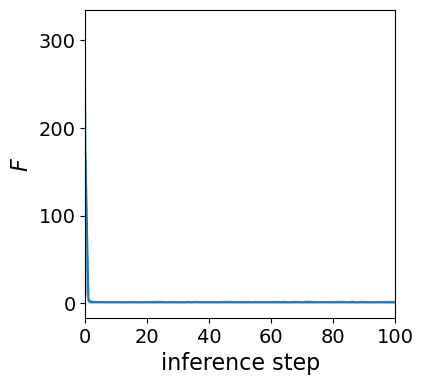

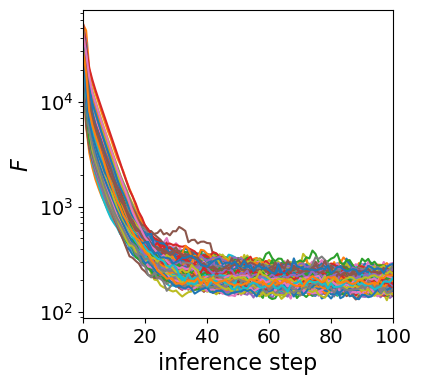

In [221]:
energy_gaus = torch.cat([m.unsqueeze(1) for m in mc_results_gaus["overall_elementwise"]], dim=1).detach().cpu()
setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  
mean = energy_gaus.mean(dim=0)
std = energy_gaus.std(dim=0)
plt.plot(mean)
plt.fill_between(range(len(mean)), [m-s for m,s in zip(mean,std)], [m+s for m,s in zip(mean,std)], alpha=0.5)
plt.xlim(-0, 100)
plt.xlabel("inference step")
plt.ylabel("$F$")
# plt.yscale('log')
# plt.savefig("figures/SI_inference_seed_gaus.svg")

energy_mnist = torch.cat([m.unsqueeze(1) for m in mc_results_mnist["overall_elementwise"]], dim=1).detach().cpu()
plt.figure()
setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  
mean = energy_mnist.mean(dim=0)
std = energy_mnist.std(dim=0)
plt.plot(energy_mnist.transpose(0,1))
# plt.fill_between(range(len(mean)), [m-s for m,s in zip(mean,std)], [m+s for m,s in zip(mean,std)], alpha=0.5)
plt.xlim(-0, 100)
plt.xlabel("inference step")
plt.ylabel("$F$")
plt.yscale('log')
# plt.savefig("figures/SI_inference_seed_mnist.svg")

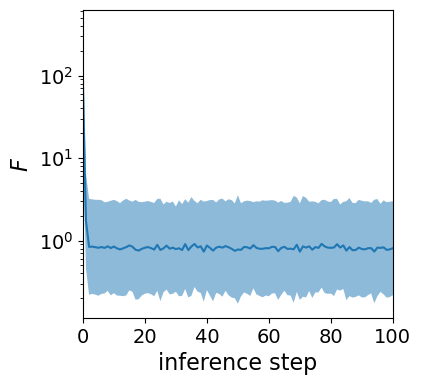

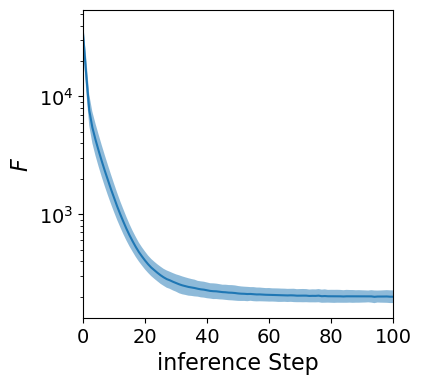

In [231]:
energy_gaus = torch.cat([m.unsqueeze(1) for m in mc_results_gaus["overall_elementwise"]], dim=1).detach().cpu()
log_ebergy_gaus = torch.log(energy_gaus)
mean_log = log_ebergy_gaus.mean(dim=0)
std_log = log_ebergy_gaus.std(dim=0)

setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  
plt.plot(torch.exp(mean_log))
plt.fill_between(range(len(mean_log)), [torch.exp(m-s) for m,s in zip(mean_log,std_log)], [torch.exp(m+s) for m,s in zip(mean_log,std_log)], alpha=0.5)
plt.xlim(-0, 100)
plt.xlabel("inference step")
plt.ylabel("$F$")
plt.yscale('log')
plt.savefig("figures/SI_inference_seed_gaus.svg")


energy_mnist = torch.cat([m.unsqueeze(1) for m in mc_results_mnist["overall_elementwise"]], dim=1).detach().cpu()
log_energy_mnist = torch.log(energy_mnist)
mean_log = log_energy_mnist.mean(dim=0)
std_log = log_energy_mnist.std(dim=0)
# Plotting
plt.figure()
setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.yscale('log')
plt.plot(torch.exp(mean_log))
plt.fill_between(range(len(mean_log)), [torch.exp(m-s) for m,s in zip(mean_log,std_log)], [torch.exp(m+s) for m,s in zip(mean_log,std_log)], alpha=0.5)
plt.xlim(-0, 100)
plt.xlabel("inference Step")
plt.ylabel("$F $")  # Label indicating the log transformation
plt.savefig("figures/SI_inference_seed_mnist.svg")
plt.show()

## Variance and covariance capture in weights

### Gaussian model

In [136]:
# network parameters
hidden_size = 1
output_size = 1

# sample a batch of data
batch_size = 512
epochs = 3
n = 25
mu=1.
vars = np.linspace(2.0, 10, 9)


# create MCPC model    
gen_mcpc = nn.Sequential(
    nn.Linear(hidden_size,hidden_size), # input zeros so that weight are disregarded and only biases are used
    pc.PCLayer(sample_x_fn=sample_x_fn_normal),
    nn.Linear(hidden_size, output_size, bias=False),
)
gen_mcpc.train()
gen_mcpc.to(device)

config = {
    "hidden_size" : 1,
    "output_size" : 1,
    "input_size" : 1,
    "input_var":1.,
    "mixing":150,
    "sampling":1,
    "optimizer_x_kwargs_mcpc":{"lr": 0.01},
    "optimizer_p_fn_mcpc": optim.Adam,
    "optimizer_p_kwargs_mcpc": {"lr": 0.1},
    "loss_fn": fe_fn 
}

# create MCPC trainer
mcpc_trainer = get_mcpc_trainer(gen_mcpc, config, training=True)

params = np.zeros((len(vars),2))
dists = []
for var in vars:
    datas = [mu + np.sqrt(var)*torch.randn(batch_size, output_size).to(device) for i in range(n)]
    pseudo_input = torch.zeros(batch_size, hidden_size).to(device)

    nn.init.constant_(gen_mcpc[0].bias, np.random.randn()) # MCPC
    nn.init.constant_(gen_mcpc[2].weight, np.random.randn()) 

    for e in (range(epochs)):
        for idx, data in enumerate(tqdm(datas)):
            mcpc_trainer.train_on_batch(inputs=pseudo_input,loss_fn=config["loss_fn"],loss_fn_kwargs={'_target': data,'_var':config["input_var"]},callback_after_t=random_step,callback_after_t_kwargs={'_pc_trainer':mcpc_trainer},is_sample_x_at_batch_start=False, is_log_progress=False,is_checking_after_callback_after_t=False)
 
    params[vars==var,0] = gen_mcpc[0].bias.item()
    params[vars==var,1] = gen_mcpc[2].weight.item()

    # get data distribution
    dists += [sample_pc(10000, gen_mcpc, config, use_cuda=use_cuda)]

dists_var = [(d.var()).cpu().numpy() for d in dists]

100%|██████████| 25/25 [00:14<00:00,  1.77it/s]


In [137]:
dists_var = [(d.var()).cpu().numpy() for d in dists]

Data variance:  2.0
Data variance:  5.0
Data variance:  7.0
Data variance:  10.0


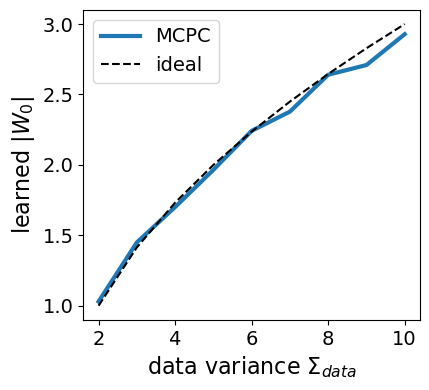

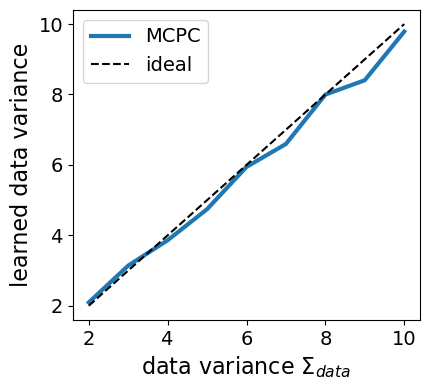

<Figure size 400x400 with 0 Axes>

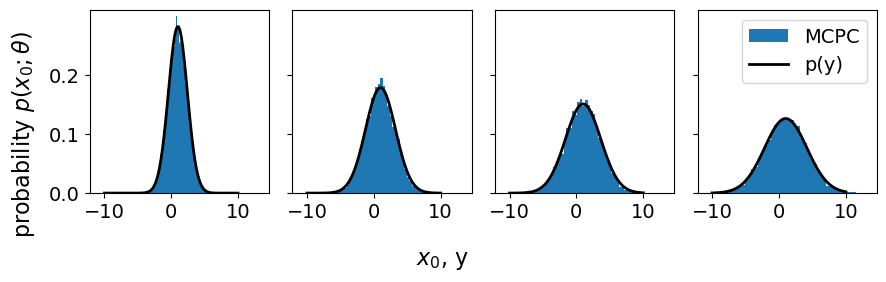

In [163]:
from matplotlib import pylab
plot_params = {'legend.fontsize': 14,
            'figure.figsize': (4.4, 4.),
            'axes.labelsize': 16,
            'axes.titlesize': 18,
            'xtick.labelsize': 14,
            'ytick.labelsize': 14}
pylab.rcParams.update(plot_params)
w_ideal = np.sqrt(vars-1)
plt.plot(vars, np.abs(params[:,1]), label="MCPC", linewidth=3)
plt.plot(vars, w_ideal, 'k--', label="ideal")
plt.xlabel("data variance $\Sigma_{data}$")
plt.ylabel("learned $|W_0|$")
plt.legend()
plt.tight_layout()
plt.savefig("figures/SI_mcpc_gauss_weight.svg")


plt.figure()
plot_params = {'legend.fontsize': 14,
            'figure.figsize': (4., 4.),
            'axes.labelsize': 16,
            'axes.titlesize': 18,
            'xtick.labelsize': 14,
            'ytick.labelsize': 14}
pylab.rcParams.update(plot_params)
w_ideal = np.sqrt(vars-1)
plt.plot(vars, dists_var, label="MCPC", linewidth=3)
plt.plot(vars, vars, 'k--', label="ideal")
plt.xlabel("data variance $\Sigma_{data}$")
plt.ylabel("learned data variance")
plt.legend()
plt.tight_layout()
plt.savefig("figures/SI_mcpc_gauss_var.svg")



plt.figure()
plot_params = {'legend.fontsize': 14,
            'figure.figsize': (9., 2.8),
            'axes.labelsize': 16,
            'axes.titlesize': 18,
            'xtick.labelsize': 14,
            'ytick.labelsize': 14}
pylab.rcParams.update(plot_params)

x = np.linspace(-10,10,100)
fig, axs = plt.subplots(nrows=1, ncols=4, sharex=True, sharey=True)
idx = 0
axs[0].hist(dists[idx].cpu().numpy(), bins=50, density=True)
axs[0].plot(x, np.exp(-(x-mu)**2/(2*vars[idx]))/np.sqrt(2*np.pi*vars[idx]), 'k', linewidth=2)
print("Data variance: ", vars[idx]) 
idx = 3
axs[1].hist(dists[idx].cpu().numpy(), bins=50, density=True)
axs[1].plot(x, np.exp(-(x-mu)**2/(2*vars[idx]))/np.sqrt(2*np.pi*vars[idx]), 'k', linewidth=2)
print("Data variance: ", vars[idx]) 
idx = 5
axs[2].hist(dists[idx].cpu().numpy(), bins=50, density=True)
axs[2].plot(x, np.exp(-(x-mu)**2/(2*vars[idx]))/np.sqrt(2*np.pi*vars[idx]), 'k', linewidth=2)
print("Data variance: ", vars[idx]) 
idx = -1
axs[3].hist(dists[idx].cpu().numpy(), bins=50, density=True, label="MCPC")
axs[3].plot(x, np.exp(-(x-mu)**2/(2*vars[idx]))/np.sqrt(2*np.pi*vars[idx]), 'k', label="p(y)", linewidth=2)
print("Data variance: ", vars[idx]) 
axs[3].set_ylim(0, 0.31)
axs[3].set_yticks([0, 0.1, 0.2])
fig.supxlabel("$x_0$, y", fontsize=16)
fig.supylabel("probability " + r"$p(x_0;\theta)$", fontsize=16)
plt.legend()
plt.tight_layout()
plt.savefig("figures/SI_mcpc_gauss_examples.svg")


### Covariance of learned sensory neurons

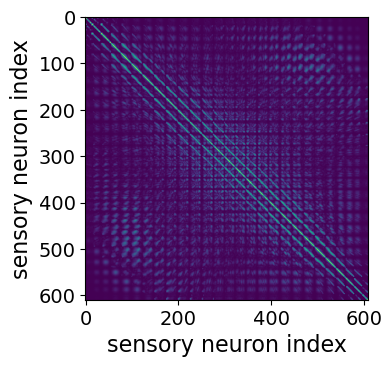

In [151]:
config = {
    "batch_size_train":256,
    "batch_size_val": 1024,
    "batch_size_test": 4000,
    #
    "loss_fn": bernoulli_fn ,
}

# Load MNIST data
train_loader, val_loader, test_loader = get_mnist_data(config)
data, labels = next(iter(test_loader))

rand = torch.rand(data.shape[0],1)*0.001
n_zeros = data[:,data.sum(0)==0].shape[1]
rand = rand.repeat(1,n_zeros)
data_corr = data[:,data.sum(0)!=0]

cor_data = np.corrcoef(data_corr.cpu().numpy().transpose())

# plot covariance matrix
setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  
plt.imshow(np.abs(cor_data))
# plt.colorbar()
plt.xlabel("sensory neuron index")
plt.ylabel("sensory neuron index")
plt.tight_layout()
plt.savefig("figures/SI_mcpc_mnist_correlation_data.svg")

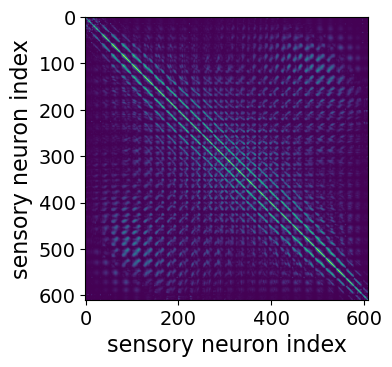

In [150]:
config = {
    "input_size": 20,
    "hidden_size": 128,
    "hidden2_size": 128,
    "output_size": 784,
    "loss_fn": bernoulli_fn ,
    "activation_fn": 'relu',
    "input_var":None,
    #
    "mixing":0,
    "sampling":300,
    "optimizer_x_kwargs_mcpc":{"lr": 0.03},
}


# get model
model = get_model(config, use_cuda)
model_name=path_models + "\mcpc_fid_1" 
model = get_model(config, use_cuda)
model.load_state_dict(torch.load(model_name),strict=False)
model.train()

generative_samples =  sample_pc(10000, model, config, use_cuda=use_cuda, is_return_hidden=True).sigmoid()
# rounding is added so that values very close to 0 are set to 0

rand = (torch.rand(generative_samples.shape[0],1)*0.001).to(generative_samples.device)
n_zeros = generative_samples[:,generative_samples.sum(0)==0].shape[1]
rand = rand.repeat(1,n_zeros)
generative_samples = generative_samples[:,data.sum(0)!=0]


cor_model = np.corrcoef(generative_samples.cpu().numpy().transpose())

# plot covariance matrix
setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  
plt.imshow(np.abs(cor_model))
# plt.colorbar()
plt.xlabel("sensory neuron index")
plt.ylabel("sensory neuron index")
plt.tight_layout()
plt.savefig("figures/SI_mcpc_mnist_correlation_model.svg")

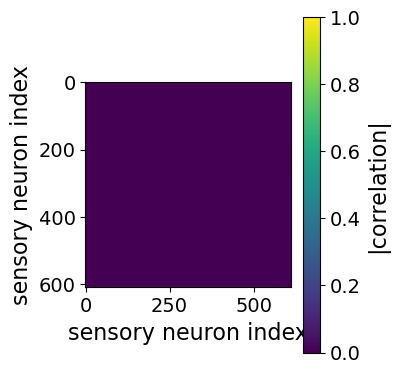

In [165]:
setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  
plt.imshow(np.zeros(cor_model.shape), vmin=0, vmax=1)
plt.colorbar( label="|correlation|", ticks=np.arange(0,1.2,0.2))
plt.xlabel("sensory neuron index")
plt.ylabel("sensory neuron index")
plt.tight_layout()
plt.savefig("figures/SI_mcpc_mnist_correlation_colorbar.svg")

# Berkes all layers

In [8]:
# import copy
# from utils.data import GratingDataset, NoiseDataset
# from utils.model import zero_fn
# from utils.training_evaluation import KLdivergence

# epochs=[0, 5, 10, 15]

# config = {
#     #
#     "EPOCHS":50,
#     "batch_size_train":256,
#     "batch_size_val": 1024,
#     "batch_size_test": 256,
#     #
#     "input_size": 20,
#     "hidden_size": 128,
#     "hidden2_size": 128,
#     "output_size": 784,
#     "loss_fn": bernoulli_fn ,
#     "activation_fn": 'relu',
#     #
#     "T_pc":1000,
#     "optimizer_x_fn_pc": optim.Adam,
#     "optimizer_x_kwargs_pc":{"lr": 0.7},
#     #
#     "mixing":50,
#     "sampling":100,
#     "optimizer_x_kwargs_mcpc":{"lr": 0.1},
#     #
#     "optimizer_p_fn_mcpc": optim.Adam,
#     "optimizer_p_kwargs_mcpc": {"lr": 0.01, "weight_decay":0.},
#     "input_var":None
# }

# # Load MNIST data
# train_loader, val_loader, test_loader = get_mnist_data(config)
# # make gratings
# grating_dataset = GratingDataset(config["batch_size_test"], size=28, num_orientations=16)
# grating_loader = DataLoader(grating_dataset, batch_size=config["batch_size_test"], shuffle=True)
# # make noise
# noise_dataset = NoiseDataset(config["batch_size_test"], size=28)
# noise_loader = DataLoader(noise_dataset, batch_size=config["batch_size_test"], shuffle=True)

# # select 5 neurons randomly
# rand_idx = [random.sample(range(config["input_size"]), 5)]
# rand_idx += [random.sample(range(config["hidden_size"]), 5)]
# rand_idx += [random.sample(range(config["hidden2_size"]), 5)]

# kls_seed=[]
# seeds = range(10)
# for seed in seeds:
#     model_name_base= path_models + "\\epoch_save\\mcpc_aging_"+str(seed)+"_"

#     indent = 20 # indent to keep only part of data to prevent memory overload
#     kls = np.zeros((3, 3,len(epochs)))
#     for idx, epoch in enumerate(epochs):
#         # get model
#         gen_pc = get_model(config, use_cuda)
#         gen_pc.train()

#         # create trainers for genaration
#         config_gen = copy.deepcopy(config)
#         config_gen["mixing"] = 500
#         config_gen["sampling"] = 9500
#         config_gen["optimizer_x_kwargs_mcpc"] = {"lr": 0.1}

#         pc_trainer_gen = get_pc_trainer(gen_pc, config_gen, is_mcpc=True, training=False)
#         mcpc_trainer_gen = get_mcpc_trainer(gen_pc, config_gen, training=False)
        
#         model_name = model_name_base + "epoch"+str(epoch) if epoch!=0 else model_name_base + "epoch_init"
#         gen_pc.load_state_dict(torch.load(model_name), strict=False)

#         # load all data
#         data, _ = list(test_loader)[0]
#         grating_data = list(grating_loader)[0]
#         noise_data = list(noise_loader)[0]
#         pseudo_input = torch.zeros(data.shape[0], config_gen["input_size"])
#         if use_cuda:
#             pseudo_input, data, grating_data, noise_data = pseudo_input.cuda(), data.cuda(), grating_data.cuda(), noise_data.cuda()

#         # get spontaneous activity
#         pc_trainer_gen.train_on_batch(inputs=pseudo_input, loss_fn=zero_fn,loss_fn_kwargs={})
#         res_mcpc_prior = mcpc_trainer_gen.train_on_batch(inputs=pseudo_input,loss_fn=zero_fn, loss_fn_kwargs={},callback_after_t=random_step,
#                                     callback_after_t_kwargs={'_pc_trainer':mcpc_trainer_gen}, #
#                                     is_sample_x_at_batch_start=False, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)

#         ## get evoked activity
#         # for natural stimuli
#         pc_trainer_gen.train_on_batch(inputs=pseudo_input, loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': data},is_log_progress=False,is_return_results_every_t=False,is_checking_after_callback_after_t=False)
#         res_mcpc = mcpc_trainer_gen.train_on_batch(inputs=pseudo_input,loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': data}, 
#                                     callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer_gen}, #
#                                     is_sample_x_at_batch_start=False, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)
#         # for gratings
#         pc_trainer_gen.train_on_batch(inputs=pseudo_input, loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': grating_data},is_log_progress=False,is_return_results_every_t=False,is_checking_after_callback_after_t=False)
#         res_mcpc_grating = mcpc_trainer_gen.train_on_batch(inputs=pseudo_input,loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': grating_data}, 
#                                     callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer_gen}, #
#                                     is_sample_x_at_batch_start=False, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)
#         # for noise
#         pc_trainer_gen.train_on_batch(inputs=pseudo_input, loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': noise_data},is_log_progress=False,is_return_results_every_t=False,is_checking_after_callback_after_t=False)
#         res_mcpc_noise = mcpc_trainer_gen.train_on_batch(inputs=pseudo_input,loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': noise_data}, 
#                                     callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer_gen}, #
#                                     is_sample_x_at_batch_start=False, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)

#         for latent in range(3):
#             prior = torch.concatenate([r[latent] for r in res_mcpc_prior["xs"][config_gen["mixing"]::]])
#             posterior_natural = torch.concatenate([r[latent] for r in res_mcpc["xs"][config_gen["mixing"]::]])
#             posterior_gratings = torch.concatenate([r[latent] for r in res_mcpc_grating["xs"][config_gen["mixing"]::]])
#             posterior_noise = torch.concatenate([r[latent] for r in res_mcpc_noise["xs"][config_gen["mixing"]::]])
            
#             ## data proprocessing
#             prior = prior[:,rand_idx[latent]]
#             posterior_natural = posterior_natural[:,rand_idx[latent]]
#             posterior_gratings = posterior_gratings[:, rand_idx[latent]]
#             posterior_noise = posterior_noise[:, rand_idx[latent]]

#             # compute KL divergence 
#             kls[latent, 0,idx] = KLdivergence(prior[::indent], posterior_natural[::indent])
#             kls[latent, 1,idx] = KLdivergence(prior[::indent], posterior_noise[::indent])
#             kls[latent, 2,idx] = KLdivergence(prior[::indent], posterior_gratings[::indent])

#         del prior, posterior_noise, posterior_gratings, posterior_natural
#     kls_seed.append(kls)

In [9]:
# kls_seed = np.array(kls_seed)

# for latent in range(3):
#     plt.figure()
#     # concatenate of data across seeds
#     kls_np = np.concatenate([k.reshape(k.shape[0],k.shape[1], 1) for k in kls_seed[:,latent,:,:]], axis=2)

#     # find mean and s.e.m.
#     kls_mean = kls_np.mean(-1)
#     kls_sem =  kls_np.std(-1)/kls_np.shape[-1]

#     # Set up the bar chart
#     conditions = [str(i) for i in epochs]
#     types = ['natural ', 'noise', 'gratings']
#     colors = ['C0', 'C1', 'C2']

#     fig, ax = plt.subplots()
#     bar_width = 0.2
#     index = np.arange(len(conditions))
#     for i, type_label in enumerate(types):
#         ax.bar(index + i * bar_width, kls_mean[i, :], bar_width, label=type_label, color=colors[i], yerr=[np.zeros_like(kls_sem[i, :])+0.05, kls_sem[i, :]], zorder=2, error_kw=dict(capsize = 4,zorder=1))

#     ax.set_ylim(0, None)
#     ax.set_ylabel('KL divergence')
#     ax.set_xlabel('Epochs')
#     ax.set_xticks(index + (bar_width * (len(types) - 1)) / 2)
#     ax.set_xticklabels(conditions)  


# Visualise reconstruction for ambiguous input

In [25]:
img_kept = 0.5

config = {
    "batch_size_train":1024,
    "batch_size_val": 1024,
    "batch_size_test": 1024,
    #
    "input_size": 20,
    "hidden_size": 128,
    "hidden2_size": 128,
    "output_size": 784,
    "loss_fn": bernoulli_fn ,
    "activation_fn": 'relu',
    "input_var":None,
    #
    "T_pc":2000,
    "optimizer_x_fn_pc": optim.Adam,
    "optimizer_x_kwargs_pc":{"lr": 0.1},
    #
    "mixing":1000,
    "sampling":3000,
    "optimizer_x_kwargs_mcpc":{"lr": 0.05},
}


# Load MNIST data
train_loader, val_loader, test_loader = get_mnist_data(config)

# get model
gen_pc = get_model(config, use_cuda)
model_name=path_models + "\mcpc_ml_2" 
gen_pc = get_model(config, use_cuda)
gen_pc.load_state_dict(torch.load(model_name),strict=False)
gen_pc.train()

# generate data
if config["loss_fn"]==fe_fn:
    loss_fn = fe_fn_mask
elif config["loss_fn"]==bernoulli_fn:
    loss_fn = bernoulli_fn_mask

# get trainers
pc_trainer = get_pc_trainer(gen_pc, config, training=False, is_mcpc=True)
mcpc_trainer = get_mcpc_trainer(gen_pc, config, training=False)

################################################## get representations  ##########################################3
print("getting representations")
rep_dataset = get_representations(gen_pc, config, [pc_trainer, mcpc_trainer], val_loader, rep_type="MAP", use_cuda=use_cuda)
representations = DataLoader(rep_dataset, batch_size=512, shuffle=False)

################################################## train linear classifier ######################################3
# make classifier
classifier = MNIST_LinearClassifier(config["input_size"])
criterion = nn.CrossEntropyLoss()
optm = optim.Adam(classifier.parameters(), lr=0.05) #, momentum=0.0
if use_cuda:
    classifier.cuda()

# train classifier
print("training classifier")
EPOCHS = 30
for epoch_idx in range(EPOCHS):
    for data, label in representations:
        loss, _ = train(classifier, data, label, optm, criterion)
    test(classifier,representations,print_acc=True)

getting representations


| l: 6.661e+04 | e: 1.763e+04 | o: 8.424e+04 |: 100%|██████████| 2000/2000 [00:11<00:00, 169.55it/s]
| l: 6.788e+04 | e: 1.746e+04 | o: 8.534e+04 |: 100%|██████████| 2000/2000 [00:11<00:00, 177.24it/s]
| l: 6.751e+04 | e: 1.761e+04 | o: 8.512e+04 |: 100%|██████████| 2000/2000 [00:11<00:00, 177.54it/s]
| l: 6.763e+04 | e: 1.776e+04 | o: 8.539e+04 |: 100%|██████████| 2000/2000 [00:11<00:00, 175.91it/s]
| l: 6.596e+04 | e: 1.762e+04 | o: 8.358e+04 |: 100%|██████████| 2000/2000 [00:11<00:00, 174.93it/s]
| l: 5.571e+04 | e: 1.555e+04 | o: 7.125e+04 |: 100%|██████████| 2000/2000 [00:11<00:00, 177.77it/s]


training classifier
Model Accuracy = tensor(0.6967, device='cuda:0')
Model Accuracy = tensor(0.7783, device='cuda:0')
Model Accuracy = tensor(0.8048, device='cuda:0')
Model Accuracy = tensor(0.8208, device='cuda:0')
Model Accuracy = tensor(0.8317, device='cuda:0')
Model Accuracy = tensor(0.8392, device='cuda:0')
Model Accuracy = tensor(0.8425, device='cuda:0')
Model Accuracy = tensor(0.8442, device='cuda:0')
Model Accuracy = tensor(0.8450, device='cuda:0')
Model Accuracy = tensor(0.8452, device='cuda:0')
Model Accuracy = tensor(0.8448, device='cuda:0')
Model Accuracy = tensor(0.8453, device='cuda:0')
Model Accuracy = tensor(0.8470, device='cuda:0')
Model Accuracy = tensor(0.8485, device='cuda:0')
Model Accuracy = tensor(0.8483, device='cuda:0')
Model Accuracy = tensor(0.8480, device='cuda:0')
Model Accuracy = tensor(0.8477, device='cuda:0')
Model Accuracy = tensor(0.8480, device='cuda:0')
Model Accuracy = tensor(0.8495, device='cuda:0')
Model Accuracy = tensor(0.8493, device='cuda:0')


In [26]:
################################################## make masked reconstruction ######################################3
digit = 4 # digit to analyse
data, label = list(test_loader)[1]
data, label = data[label==digit], label[label==digit]
pseudo_input = torch.zeros(data.shape[0],config["input_size"])
if use_cuda:
    pseudo_input, data, label = pseudo_input.cuda(), data.cuda(), label.cuda()

# perform inference with masked image
pc_results = pc_trainer.train_on_batch(inputs=pseudo_input, loss_fn=loss_fn,loss_fn_kwargs={'_target': data, '_var': config["input_var"], 'perc':img_kept}, is_log_progress=True, is_return_outputs=False, is_return_representations=True ,is_return_results_every_t=True, is_checking_after_callback_after_t=False)
mcpc_results = mcpc_trainer.train_on_batch(inputs=pseudo_input, loss_fn=loss_fn,loss_fn_kwargs={'_target': data, '_var': config["input_var"], 'perc':img_kept}, callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer}, is_sample_x_at_batch_start=False, is_return_outputs=True, is_return_representations=True, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)

# map representations to class probabilities using classifier
preds_pc = [torch.softmax(classifier(data.cuda() if use_cuda else data),1).detach().cpu() for data in pc_results["representations"]]
preds_mcpc = [torch.softmax(classifier(data.cuda() if use_cuda else data),1).detach().cpu() for data in mcpc_results["representations"]]
preds_mcpc = preds_mcpc[config['mixing']:]
# convert list of tensors to 3D tensor
preds_pc = torch.concatenate([p.view(-1,1,10) for p in preds_pc], axis=1)
preds_mcpc = torch.concatenate([p.view(-1,1,10) for p in preds_mcpc], axis=1)

# get predicted images
outputs_mcpc = torch.concatenate([o.unsqueeze(1) for o in mcpc_results["outputs"][config['mixing']:]], axis=1)

# get all latent activities
xs = []
for i in range(len(mcpc_results["xs"][0])):
    x = torch.concatenate([x[i].unsqueeze(1) for x in mcpc_results["xs"][config["mixing"]:]], axis=1)
    xs += [x]

| l: 2.614e+03 | e: 9.333e+02 | o: 3.547e+03 |: 100%|██████████| 2000/2000 [00:12<00:00, 153.95it/s]
| l: 3.139e+03 | e: 1.363e+04 | o: 1.677e+04 |: 100%|██████████| 4000/4000 [00:22<00:00, 177.79it/s]


Probability of a 4: tensor(1.0000)
Probability of a 9: tensor(0.9998)


<BarContainer object of 10 artists>

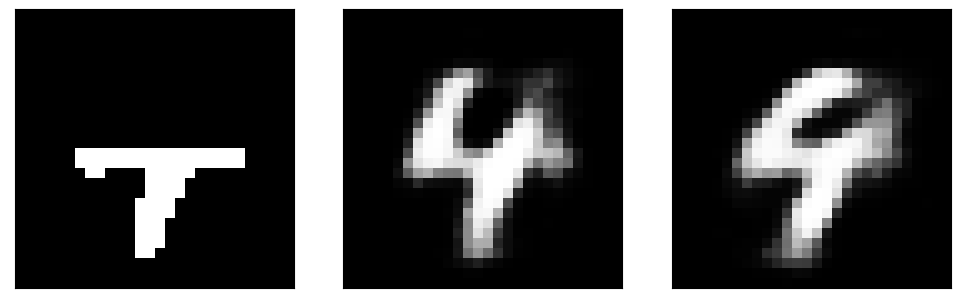

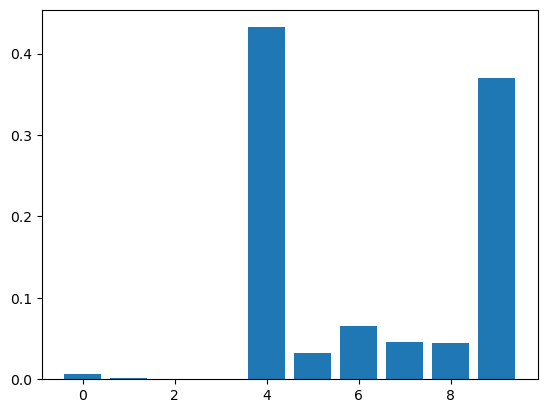

In [31]:
plt.figure(figsize=(10,30))
for img_idx in [4]:
    plt.subplot(10,3,img_idx*3+1)
    masked_img = data[img_idx].clone()
    masked_img[:int(img_kept*784)] = 0
    plt.imshow(masked_img.view(28,28).cpu().detach().numpy(), cmap='gray')
    plt.xticks([])
    plt.yticks([])

    plt.subplot(10,3,img_idx*3+2)
    print("Probability of a 4:", preds_mcpc[img_idx, preds_mcpc[img_idx, :, 4].argmax(),4])
    plt.imshow(outputs_mcpc[img_idx, preds_mcpc[img_idx,:,4].argmax(),:].sigmoid().view(28,28).cpu().detach().numpy(), cmap='gray')
    plt.xticks([])
    plt.yticks([])

    plt.subplot(10,3,img_idx*3+3)
    print("Probability of a 9:", preds_mcpc[img_idx, preds_mcpc[img_idx,:,9].argmax(),9])
    plt.imshow(outputs_mcpc[img_idx, preds_mcpc[img_idx,:,-1].argmax(),:].sigmoid().view(28,28).cpu().detach().numpy(), cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.savefig("figures/SI_masked_reconstruction.svg")

idx = 4
plt.figure()
plt.bar(range(10), preds_mcpc[idx].mean(0))

## visualised all latent layer activity using decoder and PCA and histograms

### histograms of activity

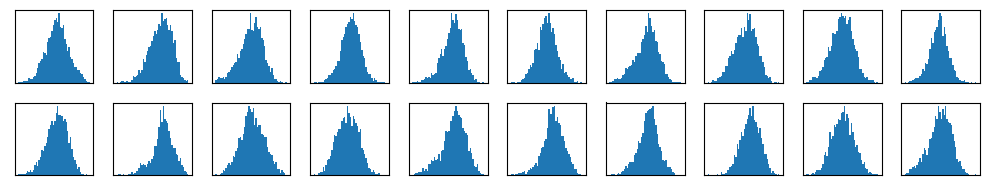

In [55]:
idx = 60
plt.figure(figsize=(10,2))
for i in range(xs[0].shape[-1]):
    plt.subplot(2,10,i+1)
    plt.hist(xs[0][idx, :, i], bins=50, density=True)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

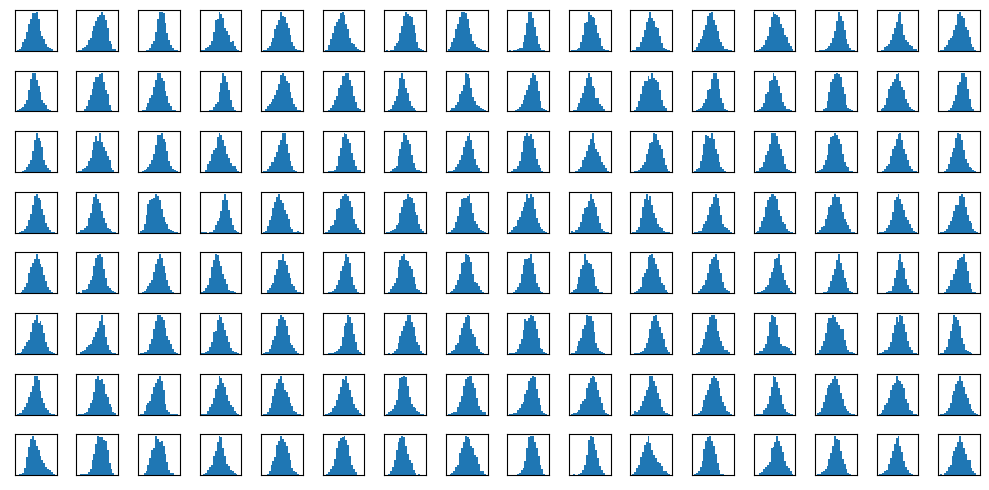

In [64]:
plt.figure(figsize=(10,5))
for i in range(xs[1].shape[-1]):
    plt.subplot(8,16,i+1)
    plt.hist(xs[1][idx, :, i], bins=20, density=True)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

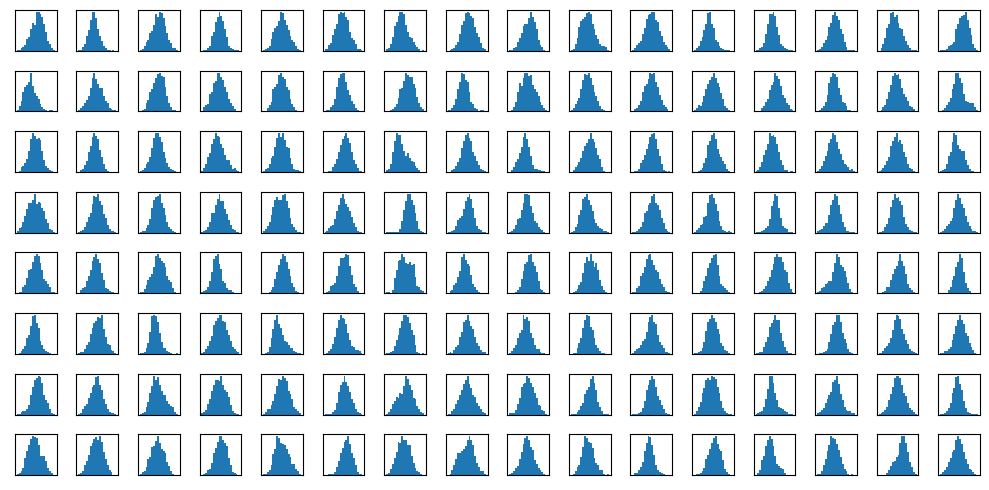

In [65]:
plt.figure(figsize=(10,5))
for i in range(xs[2].shape[-1]):
    plt.subplot(8,16,i+1)
    plt.hist(xs[2][idx, :, i], bins=20, density=True)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

### PCA

Variance explained per component: [0.08004737 0.07420531 0.07190721 0.06968178 0.06481371 0.06335148
 0.05874896 0.05629054 0.05252884 0.05061416 0.04905213 0.0475381
 0.04327267 0.0407619  0.04045804 0.03505572 0.03084463 0.03009605
 0.0241161  0.0166153 ]


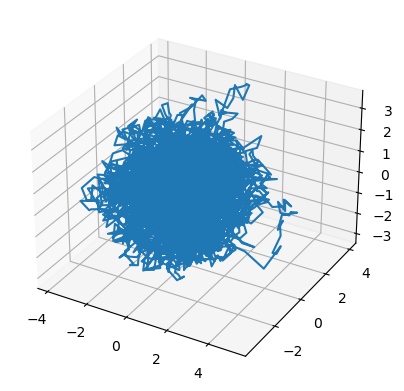

In [20]:
pca = PCA(n_components=20)
# fit PCA
rep = xs[0][idx].cpu().detach().numpy()
pca.fit(rep)
print("Variance explained per component:", pca.explained_variance_ratio_)
rep_pca = pca.transform(rep)
# plot in 3d
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(rep_pca[:,0], rep_pca[:,1], rep_pca[:,2])
# ax.view_init(elev=0, azim=270)

Variance explained per component: [0.03140024 0.028854   0.02272921 0.01936156 0.01895758 0.01743234
 0.01730064 0.015994   0.01562626 0.01527248 0.01505261 0.01459134
 0.01425237 0.01400561 0.01378002 0.01333368 0.01318015 0.01298506
 0.01280165 0.01244852 0.01227731 0.01194902 0.01165173 0.0115297
 0.01151179 0.01126041 0.01112514 0.01094493 0.01080746 0.01065414
 0.01046842 0.01032334 0.01028454 0.00991862 0.00973516 0.00959845
 0.00953074 0.00944318 0.00929021 0.00919496 0.00881784 0.00877172
 0.00868836 0.00854044 0.00844597 0.00837914 0.00814889 0.00803771
 0.00791762 0.00783967 0.00781486 0.00764466 0.00747393 0.00740446
 0.00730849 0.00717996 0.00707078 0.00696149 0.00688096 0.00686951
 0.00676735 0.00667557 0.00666476 0.00653932 0.00648448 0.00634211
 0.00631193 0.00622813 0.00612107 0.00601991 0.00595953 0.00582498
 0.00573468 0.00571533 0.00557234 0.00548472 0.0053715  0.00528757
 0.00521028 0.00513593 0.0050722  0.00497423 0.00492945 0.00480271
 0.00476116 0.00470007 0.0046

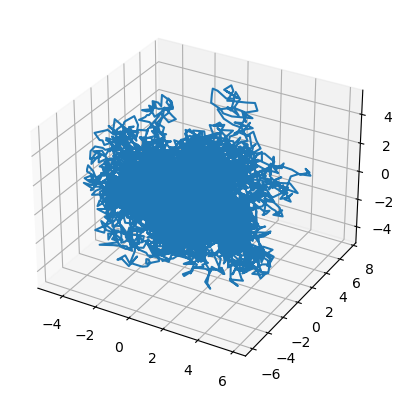

In [21]:
pca = PCA(n_components=128)
# fit PCA
rep = xs[1][idx].cpu().detach().numpy()
pca.fit(rep)
print("Variance explained per component:", pca.explained_variance_ratio_)
rep_pca = pca.transform(rep)
# plot in 3d
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(rep_pca[:,0], rep_pca[:,1], rep_pca[:,2])
# ax.view_init(elev=0, azim=270)

Variance explained per component: [0.05378724 0.05236329 0.04248505 0.03780883 0.02788713 0.02431529
 0.02084449 0.01891033 0.01673768 0.01531349 0.01422303 0.01384323
 0.0134198  0.01287373 0.01278356 0.01251056 0.01214092 0.01193503
 0.01165294 0.01134029 0.01106789 0.01101757 0.01056889 0.01044483
 0.01034955 0.01013957 0.01003084 0.00978197 0.00961137 0.00920117
 0.00908958 0.00886803 0.00879034 0.00855969 0.00843401 0.00836413
 0.00821344 0.00799504 0.00789816 0.00786569 0.00774249 0.00757874
 0.00753349 0.00745637 0.00726149 0.00719147 0.00704274 0.00696511
 0.00690263 0.00678714 0.00677593 0.00655751 0.00642235 0.00635439
 0.00630309 0.0061262  0.00600847 0.00590409 0.00587426 0.00577089
 0.00570309 0.00564925 0.00556935 0.00552411 0.00540754 0.0053597
 0.00526686 0.00524038 0.00516155 0.00510405 0.00498005 0.00478141
 0.00474521 0.00464761 0.00463662 0.00451538 0.00451216 0.00445362
 0.00435383 0.00433032 0.00429166 0.00422758 0.00413648 0.00405513
 0.0040145  0.00393884 0.0038

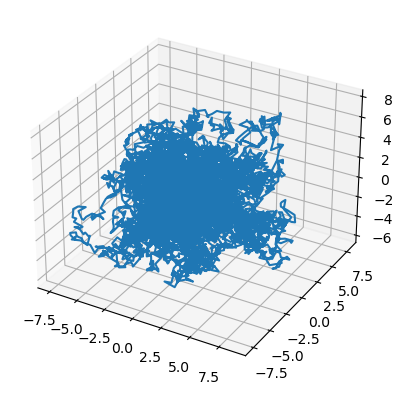

In [22]:
pca = PCA(n_components=128)
# fit PCA
rep = xs[2][idx].cpu().detach().numpy()
pca.fit(rep)
print("Variance explained per component:", pca.explained_variance_ratio_)
rep_pca = pca.transform(rep)
# plot in 3d
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(rep_pca[:,0], rep_pca[:,1], rep_pca[:,2])
# ax.view_init(elev=0, azim=270)

### Comparing latent activity for multiple classes

In [68]:
################################################## make masked reconstruction ######################################3
data, label = list(val_loader)[0]
pseudo_input = torch.zeros(data.shape[0], config["input_size"])
if use_cuda:
    pseudo_input, data, label = pseudo_input.cuda(), data.cuda(), label.cuda()


# take 10 images of each digit
imgs = []
labels = []
for i in range(10):
    imgs += [data[label==i][:10]]
    labels += [label[label==i][:10]]
imgs = torch.cat(imgs, dim=0)
labels = torch.cat(labels, dim=0)

pseudo_input = torch.zeros(imgs.shape[0], config["input_size"])

imgs, pseudo_input = imgs.to(device), pseudo_input.to(device)

# perform inference with masked image
mcpc_results_digits = mcpc_trainer.train_on_batch(inputs=pseudo_input, loss_fn=bernoulli_fn, loss_fn_kwargs={'_target': imgs, '_var': config["input_var"]}, callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer}, is_sample_x_at_batch_start=False, is_return_outputs=True, is_return_representations=True, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)
mcpc_results_digits_masked = mcpc_trainer.train_on_batch(inputs=pseudo_input, loss_fn=bernoulli_fn_mask, loss_fn_kwargs={'_target': imgs, '_var': config["input_var"]}, callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer}, is_sample_x_at_batch_start=False, is_return_outputs=True, is_return_representations=True, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)

| l: 7.590e+03 | e: 1.552e+04 | o: 2.311e+04 |: 100%|██████████| 4000/4000 [00:26<00:00, 150.00it/s]
| l: 3.971e+03 | e: 1.502e+04 | o: 1.899e+04 |: 100%|██████████| 4000/4000 [00:24<00:00, 164.38it/s]


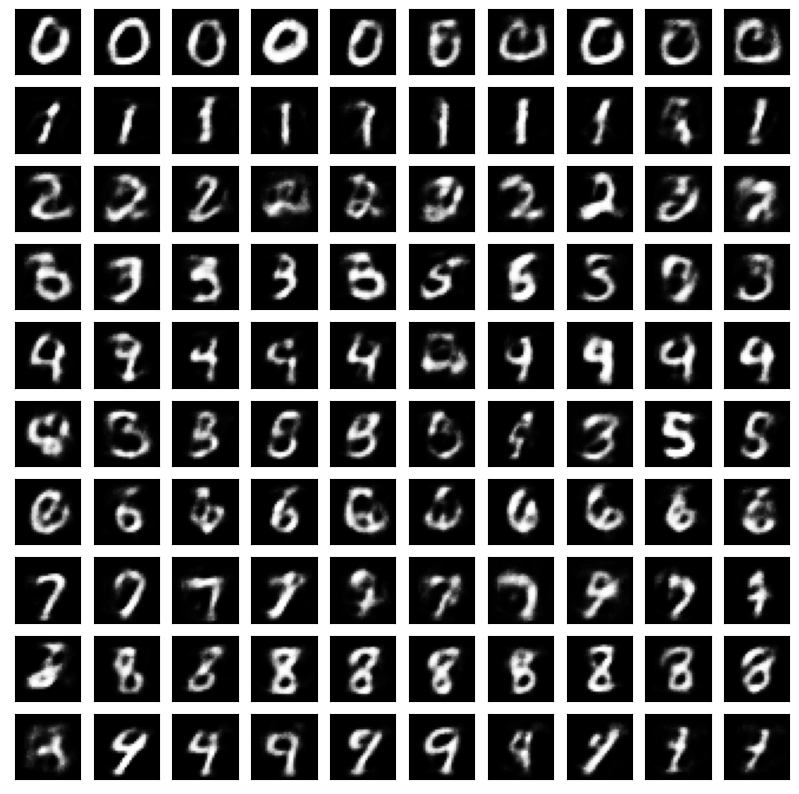

In [69]:
# plot the 100 masked images
plt.figure(figsize=(10,10))
for i in range(100):
    plt.subplot(10,10,i+1)
    plt.imshow(mcpc_results_digits_masked["outputs"][-1][i].sigmoid().view(28,28).cpu().detach().numpy(), cmap='gray')
    plt.xticks([])
    plt.yticks([])

In [70]:
xs_digits = []
for i in range(len(mcpc_results_digits["xs"][0])):
    x = torch.concatenate([x[i].unsqueeze(1) for x in mcpc_results_digits["xs"][config["mixing"]:]], axis=1)
    xs_digits += [x]

xs_digits_masked = []
for i in range(len(mcpc_results_digits_masked["xs"][0])):
    x = torch.concatenate([x[i].unsqueeze(1) for x in mcpc_results_digits_masked["xs"][config["mixing"]:]], axis=1)
    xs_digits_masked += [x]

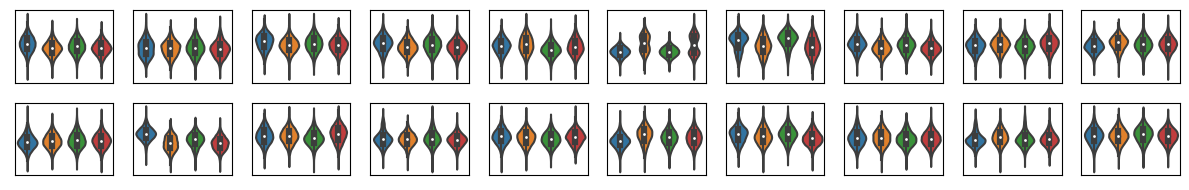

In [81]:
data_pair = [4, 9]
labels = labels.cpu()
plt.figure(figsize=(12,2))
for i in range(xs_digits[0].shape[-1]):
    plt.subplot(2,10,i+1)
    data_plot = []
    for j in data_pair:
        data_plot.append(xs_digits[0][labels==j,:,i].view(-1))
    for j in data_pair:
        data_plot.append(xs_digits_masked[0][labels==j,:,i].view(-1))
    sns.violinplot(data=data_plot)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

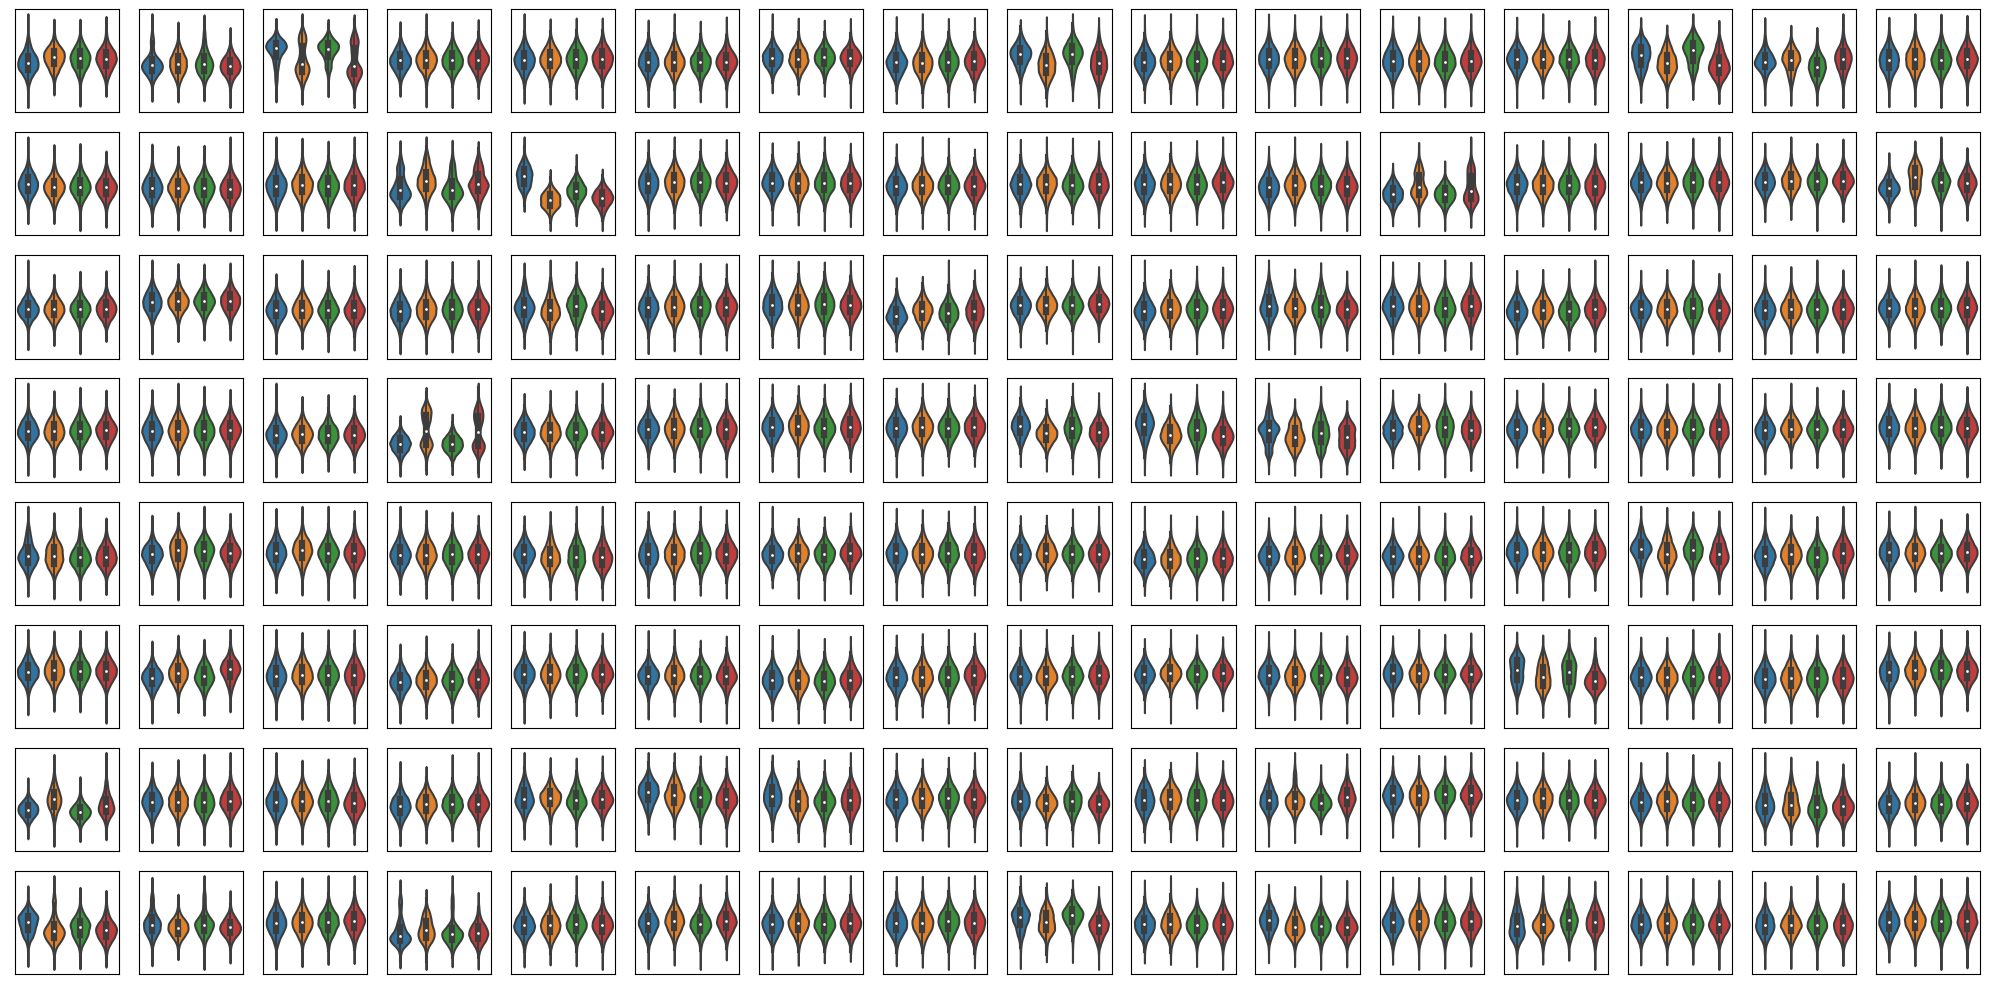

In [82]:
labels = labels.cpu()
plt.figure(figsize=(20,10))
for i in range(xs_digits[1].shape[-1]):
    plt.subplot(8,16,i+1)
    data_plot = []
    for j in data_pair:
        data_plot.append(xs_digits[1][labels==j,:,i].view(-1))
    for j in data_pair:
        data_plot.append(xs_digits_masked[1][labels==j,:,i].view(-1))
    sns.violinplot(data=data_plot)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

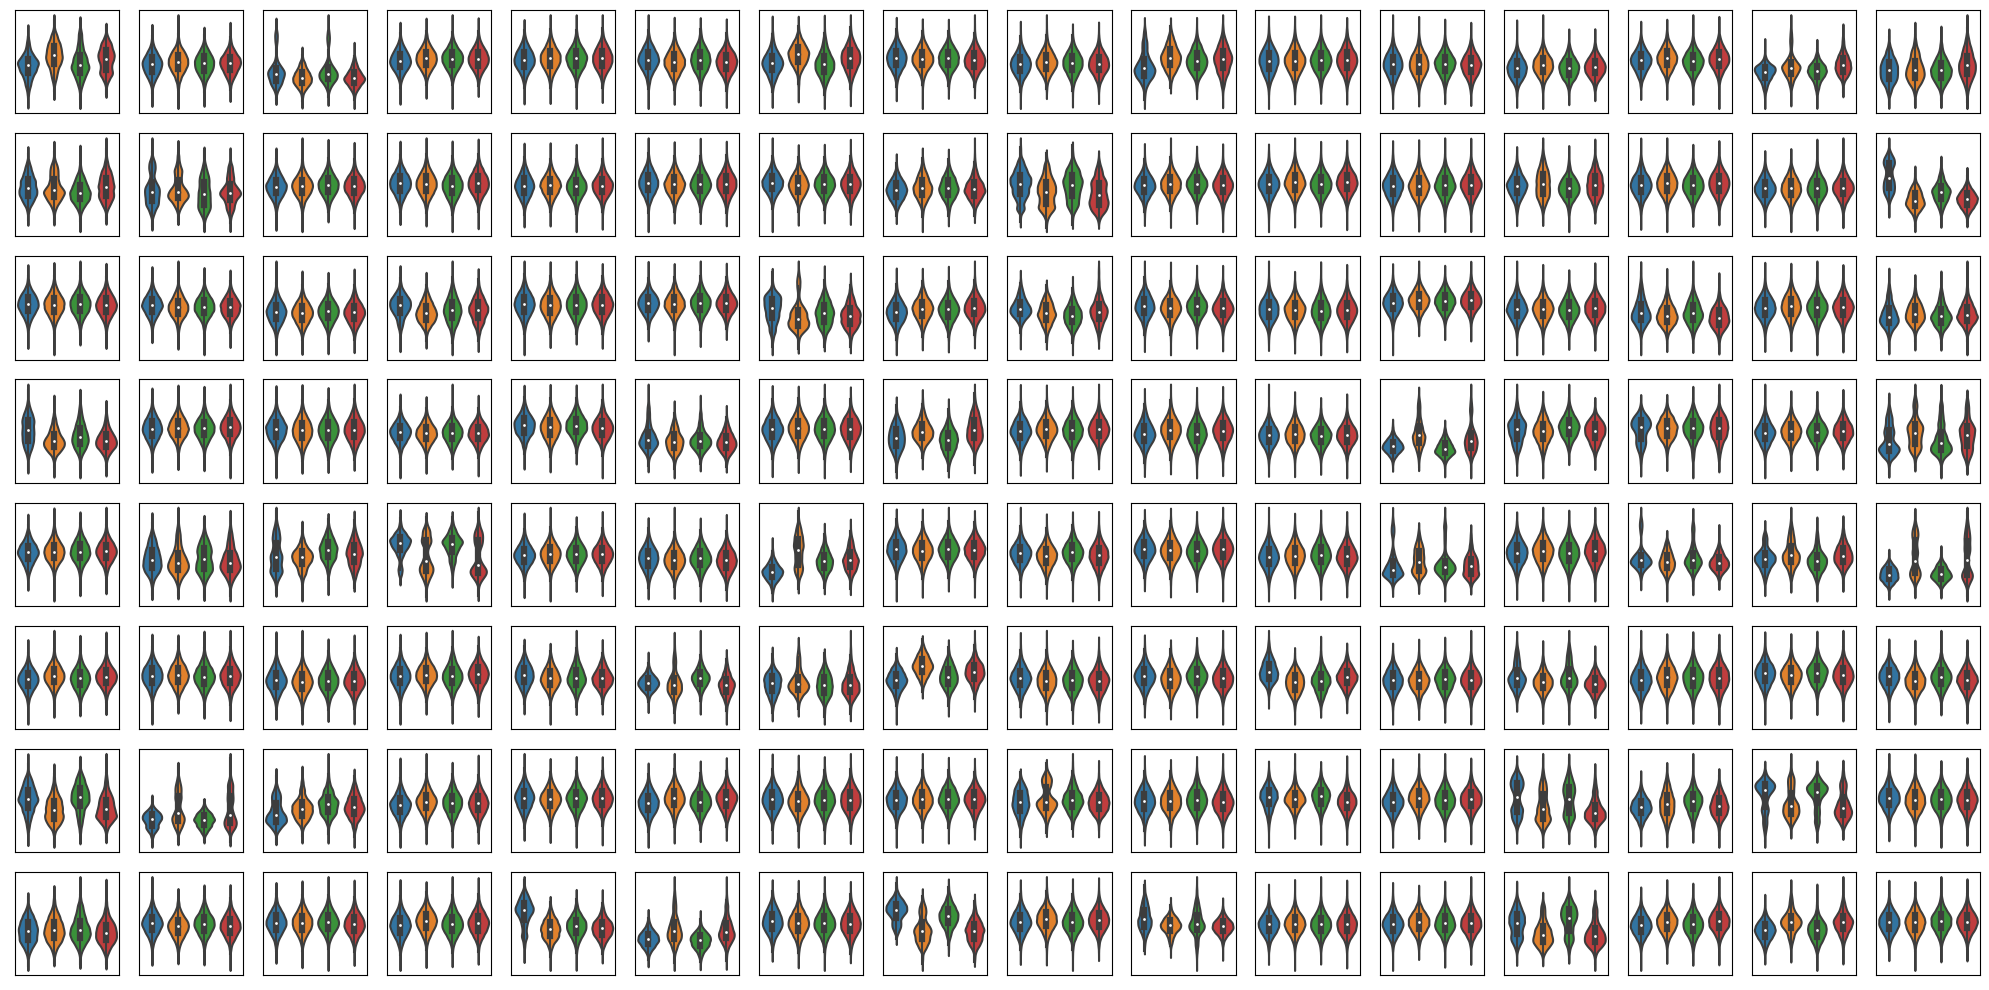

In [83]:
labels = labels.cpu()
plt.figure(figsize=(20,10))
for i in range(xs_digits[2].shape[-1]):
    plt.subplot(8,16,i+1)
    plot_data = []
    for j in data_pair:
        plot_data.append(xs_digits[2][labels==j,:,i].view(-1))
    for j in data_pair:
        plot_data.append(xs_digits_masked[2][labels==j,:,i].view(-1))
    sns.violinplot(data=plot_data)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

In [96]:
pca_data = []
pca_labels = []

for j in data_pair:
    pca_data.append(xs_digits[2][labels==j,:,:].view(-1, xs_digits[2].shape[-1]))
    pca_labels += [j*torch.ones(pca_data[-1].shape[0])]
pca_data = torch.cat(pca_data, dim=0)
pca_labels = torch.cat(pca_labels, dim=0)

pca = PCA(n_components=20)
rep_pca = pca.fit_transform(pca_data)
print("Variance explained per component:", pca.explained_variance_ratio_)

Variance explained per component: [0.20601899 0.09169485 0.07106592 0.06147543 0.0478645  0.03718132
 0.03216407 0.02748683 0.02075738 0.01888705 0.01583688 0.01290961
 0.00975413 0.00909975 0.00832109 0.00705756 0.00701535 0.00561947
 0.00545989 0.00531721]


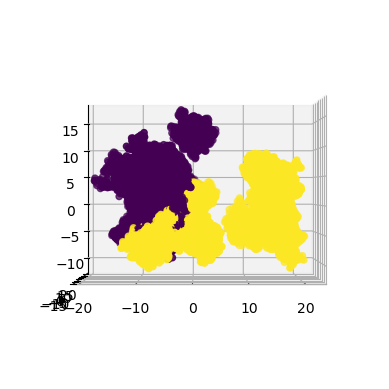

In [125]:
# plot in 3d
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rep_pca[:,0], rep_pca[:,1], rep_pca[:,2], c = pca_labels.numpy().astype(int))
ax.view_init(elev=0, azim=270)

In [110]:
pca_data_masked = []
pca_labels_masked = []

for j in [data_pair[0]]:
    pca_data_masked.append(xs_digits_masked[2][labels==j,:,:].view(-1, xs_digits_masked[2].shape[-1]))
    pca_labels_masked += [j*torch.ones(pca_data_masked[-1].shape[0])]
pca_data_masked = torch.cat(pca_data_masked, dim=0)
pca_labels_masked = torch.cat(pca_labels_masked, dim=0)

rep_masked = pca.transform(pca_data_masked)

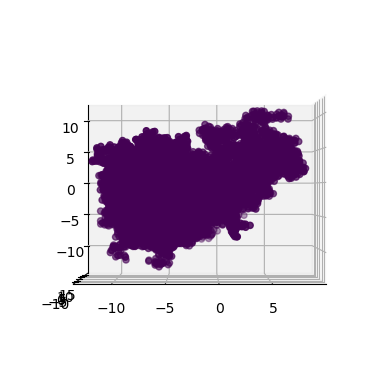

In [124]:
# plot in 3d
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rep_masked[:,0], rep_masked[:,1], rep_masked[:,2], c = pca_labels_masked.numpy().astype(int))
ax.view_init(elev=0, azim=270)

## decoded activity in all layers

In [19]:
img_kept = 0.5

config = {
    "batch_size_train":1024,
    "batch_size_val": 1024,
    "batch_size_test": 1024,
    #
    "input_size": 20,
    "hidden_size": 128,
    "hidden2_size": 128,
    "output_size": 784,
    "loss_fn": bernoulli_fn ,
    "activation_fn": 'relu',
    "input_var":None,
    #
    "T_pc":2000,
    "optimizer_x_fn_pc": optim.Adam,
    "optimizer_x_kwargs_pc":{"lr": 0.1},
    #
    "mixing":1000,
    "sampling":3000,
    "optimizer_x_kwargs_mcpc":{"lr": 0.05},
}


# Load MNIST data
train_loader, val_loader, test_loader = get_mnist_data(config)

# get model
gen_pc = get_model(config, use_cuda)
model_name=path_models + "\mcpc_ml_2" 
gen_pc = get_model(config, use_cuda)
gen_pc.load_state_dict(torch.load(model_name),strict=False)
gen_pc.train()

# generate data
if config["loss_fn"]==fe_fn:
    loss_fn = fe_fn_mask
elif config["loss_fn"]==bernoulli_fn:
    loss_fn = bernoulli_fn_mask

# get trainers
pc_trainer = get_pc_trainer(gen_pc, config, training=False, is_mcpc=True)
mcpc_trainer = get_mcpc_trainer(gen_pc, config, training=False)

################################################## get representations  ##########################################3
print("getting representations")
xs_datasets = get_xs(gen_pc, config, pc_trainer, val_loader, use_cuda=use_cuda)


################################################## train linear classifiers ######################################3
decoders = []
for rep_dataset in xs_datasets:
    representations = DataLoader(rep_dataset, batch_size=512, shuffle=False)
    rep_dataset.__getitem__(0)[0].shape[-1]
    # make classifier
    classifier = MNIST_LinearClassifier(rep_dataset.__getitem__(0)[0].shape[-1])
    criterion = nn.CrossEntropyLoss()
    optm = optim.Adam(classifier.parameters(), lr=0.05) #, momentum=0.0
    if use_cuda:
        classifier.cuda()

    # train classifier
    print("training classifier")
    EPOCHS = 30
    for epoch_idx in range(EPOCHS):
        for data, label in representations:
            loss, _ = train(classifier, data, label, optm, criterion)
        if epoch_idx%5==0:
            test(classifier,representations,print_acc=True)
    decoders.append(classifier)

getting representations


| l: 6.661e+04 | e: 1.764e+04 | o: 8.424e+04 |: 100%|██████████| 2000/2000 [00:09<00:00, 200.19it/s]
| l: 6.791e+04 | e: 1.745e+04 | o: 8.535e+04 |: 100%|██████████| 2000/2000 [00:09<00:00, 216.35it/s]
| l: 6.752e+04 | e: 1.760e+04 | o: 8.511e+04 |: 100%|██████████| 2000/2000 [00:09<00:00, 220.50it/s]
| l: 6.763e+04 | e: 1.776e+04 | o: 8.539e+04 |: 100%|██████████| 2000/2000 [00:09<00:00, 217.76it/s]
| l: 6.597e+04 | e: 1.762e+04 | o: 8.359e+04 |: 100%|██████████| 2000/2000 [00:09<00:00, 216.41it/s]
| l: 5.570e+04 | e: 1.555e+04 | o: 7.125e+04 |: 100%|██████████| 2000/2000 [00:09<00:00, 217.01it/s]


torch.Size([6000, 20]) torch.Size([6000])
training classifier
Model Accuracy = tensor(0.7268, device='cuda:0')
Model Accuracy = tensor(0.8290, device='cuda:0')
Model Accuracy = tensor(0.8455, device='cuda:0')
Model Accuracy = tensor(0.8477, device='cuda:0')
Model Accuracy = tensor(0.8493, device='cuda:0')
Model Accuracy = tensor(0.8508, device='cuda:0')
training classifier
Model Accuracy = tensor(0.6717, device='cuda:0')
Model Accuracy = tensor(0.8730, device='cuda:0')
Model Accuracy = tensor(0.8798, device='cuda:0')
Model Accuracy = tensor(0.8818, device='cuda:0')
Model Accuracy = tensor(0.8823, device='cuda:0')
Model Accuracy = tensor(0.8823, device='cuda:0')
training classifier
Model Accuracy = tensor(0.7685, device='cuda:0')
Model Accuracy = tensor(0.8770, device='cuda:0')
Model Accuracy = tensor(0.8830, device='cuda:0')
Model Accuracy = tensor(0.8837, device='cuda:0')
Model Accuracy = tensor(0.8810, device='cuda:0')
Model Accuracy = tensor(0.8870, device='cuda:0')


In [20]:
digit = 4 # digit to analyse
data, label = list(test_loader)[1]
data, label = data[label==digit], label[label==digit]
pseudo_input = torch.zeros(data.shape[0], config["input_size"])
if use_cuda:
    pseudo_input, data, label = pseudo_input.cuda(), data.cuda(), label.cuda()

# perform inference with masked image
pc_results = pc_trainer.train_on_batch(inputs=pseudo_input, loss_fn=loss_fn,loss_fn_kwargs={'_target': data, '_var': config["input_var"], 'perc':img_kept}, is_log_progress=True, is_return_outputs=False, is_return_representations=False, is_return_results_every_t=False, is_checking_after_callback_after_t=False, is_return_xs=True)
mcpc_results = mcpc_trainer.train_on_batch(inputs=pseudo_input, loss_fn=loss_fn,loss_fn_kwargs={'_target': data, '_var': config["input_var"], 'perc':img_kept}, callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer}, is_sample_x_at_batch_start=False, is_return_outputs=False, is_return_representations=False, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)

| l: 2.613e+03 | e: 9.334e+02 | o: 3.547e+03 |: 100%|██████████| 2000/2000 [00:13<00:00, 151.47it/s]
| l: 3.026e+03 | e: 1.362e+04 | o: 1.665e+04 |: 100%|██████████| 4000/4000 [00:27<00:00, 145.12it/s]


In [21]:
xs_pc = []
for i in range(len(pc_results["xs"][0])):
    x = torch.concatenate([x[i].unsqueeze(1) for x in pc_results["xs"]], axis=1)
    xs_pc += [x]

xs_mcpc = []
for i in range(len(mcpc_results["xs"][0])):
    x = torch.concatenate([x[i].unsqueeze(1) for x in mcpc_results["xs"]], axis=1)
    xs_mcpc += [x]

In [23]:
for layer_idx, (classifier, x_pc, x_mcpc) in enumerate(zip(decoders, xs_pc, xs_mcpc)):
    preds_pc = torch.softmax(classifier(x_pc.squeeze().cuda() if use_cuda else x_pc.squeeze()), 1).detach().cpu()
    preds_mcpc = [torch.softmax(classifier(x_mcpc[:,i,:].cuda() if use_cuda else x_mcpc[:,i,:]), 1).detach().cpu() for i in range(x_mcpc.shape[1])]

    preds_mcpc = preds_mcpc[config['mixing']:]

    # convert list of tensors to 3D tensor
    preds_pc = preds_pc.view(-1,1,10)
    preds_mcpc = torch.concatenate([p.view(-1,1,10) for p in preds_mcpc], axis=1)

    gridsize=20
    file_type = "full" if img_kept==1. else "masked"
    for idx_batch in range(10):
        img = data[idx_batch].clone()
        img[:round(len(img)*(1-img_kept))] = 0.
        
        ## make recap plot
        # get coors
        coor_pc, _ = proba_to_coordinate(preds_pc[idx_batch, -1, :])
        coor_previous, class_coor  = proba_to_coordinate(preds_mcpc[idx_batch, :,:])
        # make plot
        fig, axs = plt.subplots(1, 1, constrained_layout=True)
        axs.set_aspect('equal')
        plt.axis('off')
        axs.hexbin(coor_previous[0],coor_previous[1], gridsize=gridsize, cmap='Blues', bins=preds_mcpc.shape[1],extent=(-1, 1, -1, 1), label="MCPC")
        for idx in range(10):
            axs.text(1.15*class_coor[0][idx]-0.038,1.15*class_coor[1][idx]-0.04,str(idx),fontsize=20)    
        axs.scatter(coor_pc[0][0],coor_pc[1][0], c="red", linewidths=6, marker="o", facecolor='none', label="PC")
        axs.set_xlim([-1.2,1.2])
        axs.set_ylim([-1.2,1.2])
        plt.legend(fontsize=14, loc=3)
        plt.savefig("figures/digit_posteriors_all_layers/"+str(layer_idx)+file_type +"_"+str(idx_batch)+".svg")
        plt.close()


# features learned by hierarchical neurons

In [185]:
config = {
    "batch_size_train":1024,
    "batch_size_val": 1024,
    "batch_size_test": 1024,
    #
    "input_size": 20,
    "hidden_size": 128,
    "hidden2_size": 128,
    "output_size": 784,
    "loss_fn": bernoulli_fn ,
    "activation_fn": 'relu',
    "input_var":None,
    #
    "T_pc":2000,
    "optimizer_x_fn_pc": optim.Adam,
    "optimizer_x_kwargs_pc":{"lr": 0.1},
    #
    "mixing":1000,
    "sampling":3000,
    "optimizer_x_kwargs_mcpc":{"lr": 0.05},
}


# Load MNIST data
train_loader, val_loader, test_loader = get_mnist_data(config)

# get model
gen_pc = get_model(config, use_cuda)
model_name=path_models + "\mcpc_fid_2" 
gen_pc = get_model(config, use_cuda)
gen_pc.load_state_dict(torch.load(model_name, map_location="cuda"), strict=False)
gen_pc.eval()

gen_pc

Sequential(
  (0): Linear(in_features=20, out_features=20, bias=True)
  (1): PCLayer()
  (2): ReLU()
  (3): Linear(in_features=20, out_features=128, bias=True)
  (4): PCLayer()
  (5): ReLU()
  (6): Linear(in_features=128, out_features=128, bias=True)
  (7): PCLayer()
  (8): ReLU()
  (9): Linear(in_features=128, out_features=784, bias=True)
)

In [186]:
# load mnist classifier
from ResNet9 import ResNet9
name = path_models +"/resnet9"
resnet = ResNet9().cuda()
resnet.load_state_dict(torch.load(name),strict=False)


<All keys matched successfully>

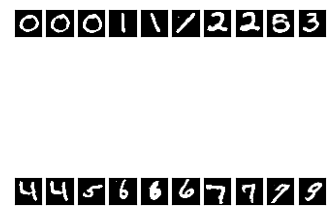

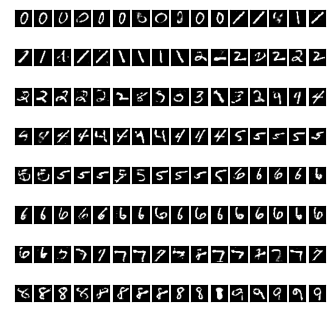

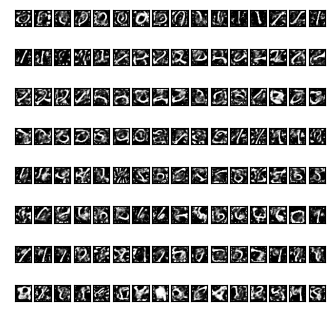

In [189]:
outputs = []
for i in range(20):
    # generate latent activity
    activity = torch.zeros(1, config["input_size"]) 
    activity[0,i] = 10. # (modify this value to get different digits)
    activity = activity.cuda() if use_cuda else activity
    outputs.append(gen_pc[1:](activity).sigmoid())

outputs = torch.cat(outputs, dim=0)
# predict class of each image
probability = torch.softmax(resnet(outputs.view(-1,1,28,28)), 1).detach().cpu().numpy()
probability = probability.argmax(axis=1)
# sort images by ascending class
idx_sort = np.argsort(probability)
outputs = outputs[idx_sort]

for i in range(20):
    plt.subplot(2,10,i+1)
    # predict
    plt.imshow(outputs[i].view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.savefig("figures/SI_features_hL.svg")
plt.show()


# repeat for hidden layer 1
outputs = []
for i in range(config["hidden_size"]):
    # generate latent activity
    activity = torch.zeros(1, config["hidden_size"]) 
    activity[0,i] = 10.
    activity = activity.cuda() if use_cuda else activity
    outputs.append(gen_pc[4:](activity).sigmoid())

outputs = torch.cat(outputs, dim=0)
# predict class of each image
probability = torch.softmax(resnet(outputs.view(-1,1,28,28)), 1).detach().cpu().numpy()
probability = probability.argmax(axis=1)
# sort images by ascending class
idx_sort = np.argsort(probability)
outputs = outputs[idx_sort]

for i in range(config["hidden_size"]):
    plt.subplot(8,16,i+1)
    # predict
    plt.imshow(outputs[i].view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.savefig("figures/SI_features_hL_1.svg")
plt.show()

# repeat for hidden layer 2
outputs = []
for i in range(config["hidden_size"]):
    # generate latent activity
    activity = torch.zeros(1, config["hidden_size"]) 
    activity[0,i] = 10
    activity = activity.cuda() if use_cuda else activity
    outputs.append(gen_pc[7:](activity).sigmoid())

outputs = torch.cat(outputs, dim=0)
# predict class of each image
probability = torch.softmax(resnet(outputs.view(-1,1,28,28)), 1).detach().cpu().numpy()
probability = probability.argmax(axis=1)
# sort images by ascending class
idx_sort = np.argsort(probability)
outputs = outputs[idx_sort]

for i in range(config["hidden_size"]):
    plt.subplot(8,16,i+1)
    # predict
    plt.imshow(outputs[i].view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.savefig("figures/SI_features_hL_2.svg")
plt.show()

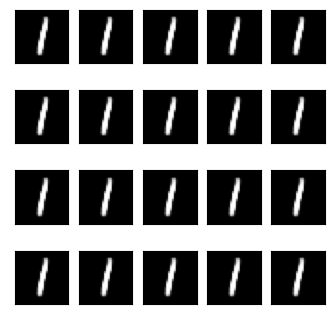

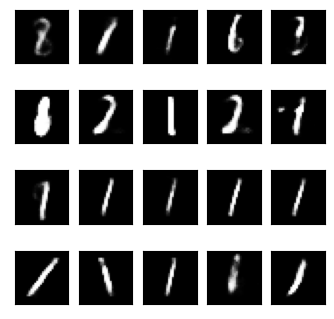

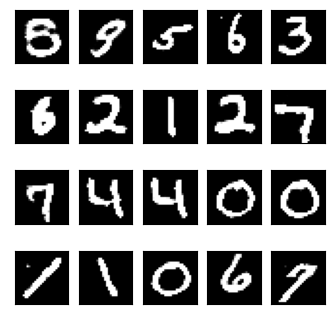

In [80]:
for i in range(20):
    plt.subplot(4,5,i+1)
    # generate latent activity
    activity = torch.zeros(1, config["input_size"]) 
    activity[0,i] = 0. # (modify this value to get different digits)
    activity = activity.cuda() if use_cuda else activity
    output = gen_pc[1:](activity).sigmoid()
    plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.show()

for i in range(20):
    plt.subplot(4,5,i+1)
    # generate latent activity
    activity = torch.zeros(1, config["input_size"]) 
    activity[0,i] = 2. # (modify this value to get different digits)
    activity = activity.cuda() if use_cuda else activity
    output = gen_pc[1:](activity).sigmoid()
    plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.show()

for i in range(20):
    plt.subplot(4,5,i+1)
    # generate latent activity
    activity = torch.zeros(1, config["input_size"]) 
    activity[0,i] = 10. # (modify this value to get different digits)
    activity = activity.cuda() if use_cuda else activity
    output = gen_pc[1:](activity).sigmoid()
    plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.savefig("figures/SI_features_hL.svg")
plt.show()

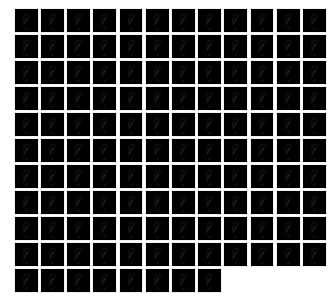

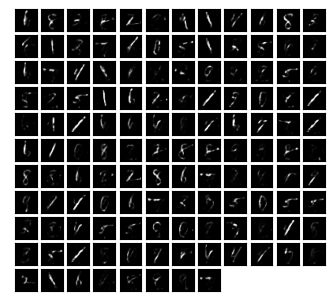

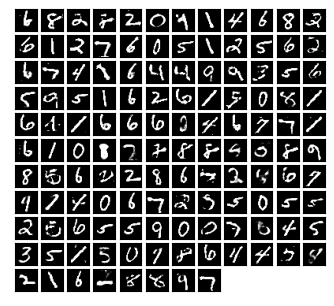

In [81]:
for i in range(config["hidden_size"]):
    plt.subplot(12,12,i+1)
    # generate latent activity
    activity = torch.zeros(1, config["hidden_size"]) 
    activity[0,i] = 0.
    activity = activity.cuda() if use_cuda else activity
    output = gen_pc[4:](activity).sigmoid()
    plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.show()

for i in range(config["hidden_size"]):
    plt.subplot(12,12,i+1)
    # generate latent activity
    activity = torch.zeros(1, config["hidden_size"]) 
    activity[0,i] = 2.
    activity = activity.cuda() if use_cuda else activity
    output = gen_pc[4:](activity).sigmoid()
    plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.show()

for i in range(config["hidden_size"]):
    plt.subplot(12,12,i+1)
    # generate latent activity
    activity = torch.zeros(1, config["hidden_size"]) 
    activity[0,i] = 10.
    activity = activity.cuda() if use_cuda else activity
    output = gen_pc[4:](activity).sigmoid()
    plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.savefig("figures/SI_features_hL_1.svg")
plt.show()

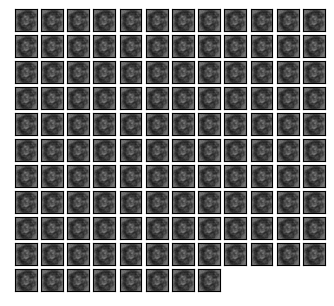

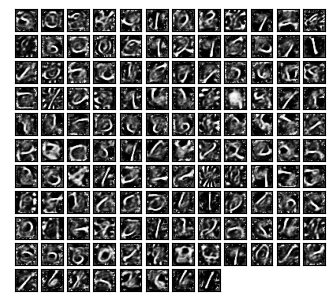

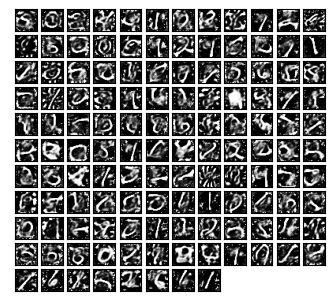

In [82]:
for i in range(config["hidden_size"]):
    plt.subplot(12,12,i+1)
    # generate latent activity
    activity = torch.zeros(1, config["hidden_size"]) 
    activity[0,i] = 0
    activity = activity.cuda() if use_cuda else activity
    output = gen_pc[7:](activity).sigmoid()
    plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.show()

for i in range(config["hidden_size"]):
    plt.subplot(12,12,i+1)
    # generate latent activity
    activity = torch.zeros(1, config["hidden_size"]) 
    activity[0,i] = 5
    activity = activity.cuda() if use_cuda else activity
    output = gen_pc[7:](activity).sigmoid()
    plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.show()

for i in range(config["hidden_size"]):
    plt.subplot(12,12,i+1)
    # generate latent activity
    activity = torch.zeros(1, config["hidden_size"]) 
    activity[0,i] = 10
    activity = activity.cuda() if use_cuda else activity
    output = gen_pc[7:](activity).sigmoid()
    plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)    
    plt.xticks([])
    plt.yticks([])
plt.savefig("figures/SI_features_hL_2.svg")
plt.show()

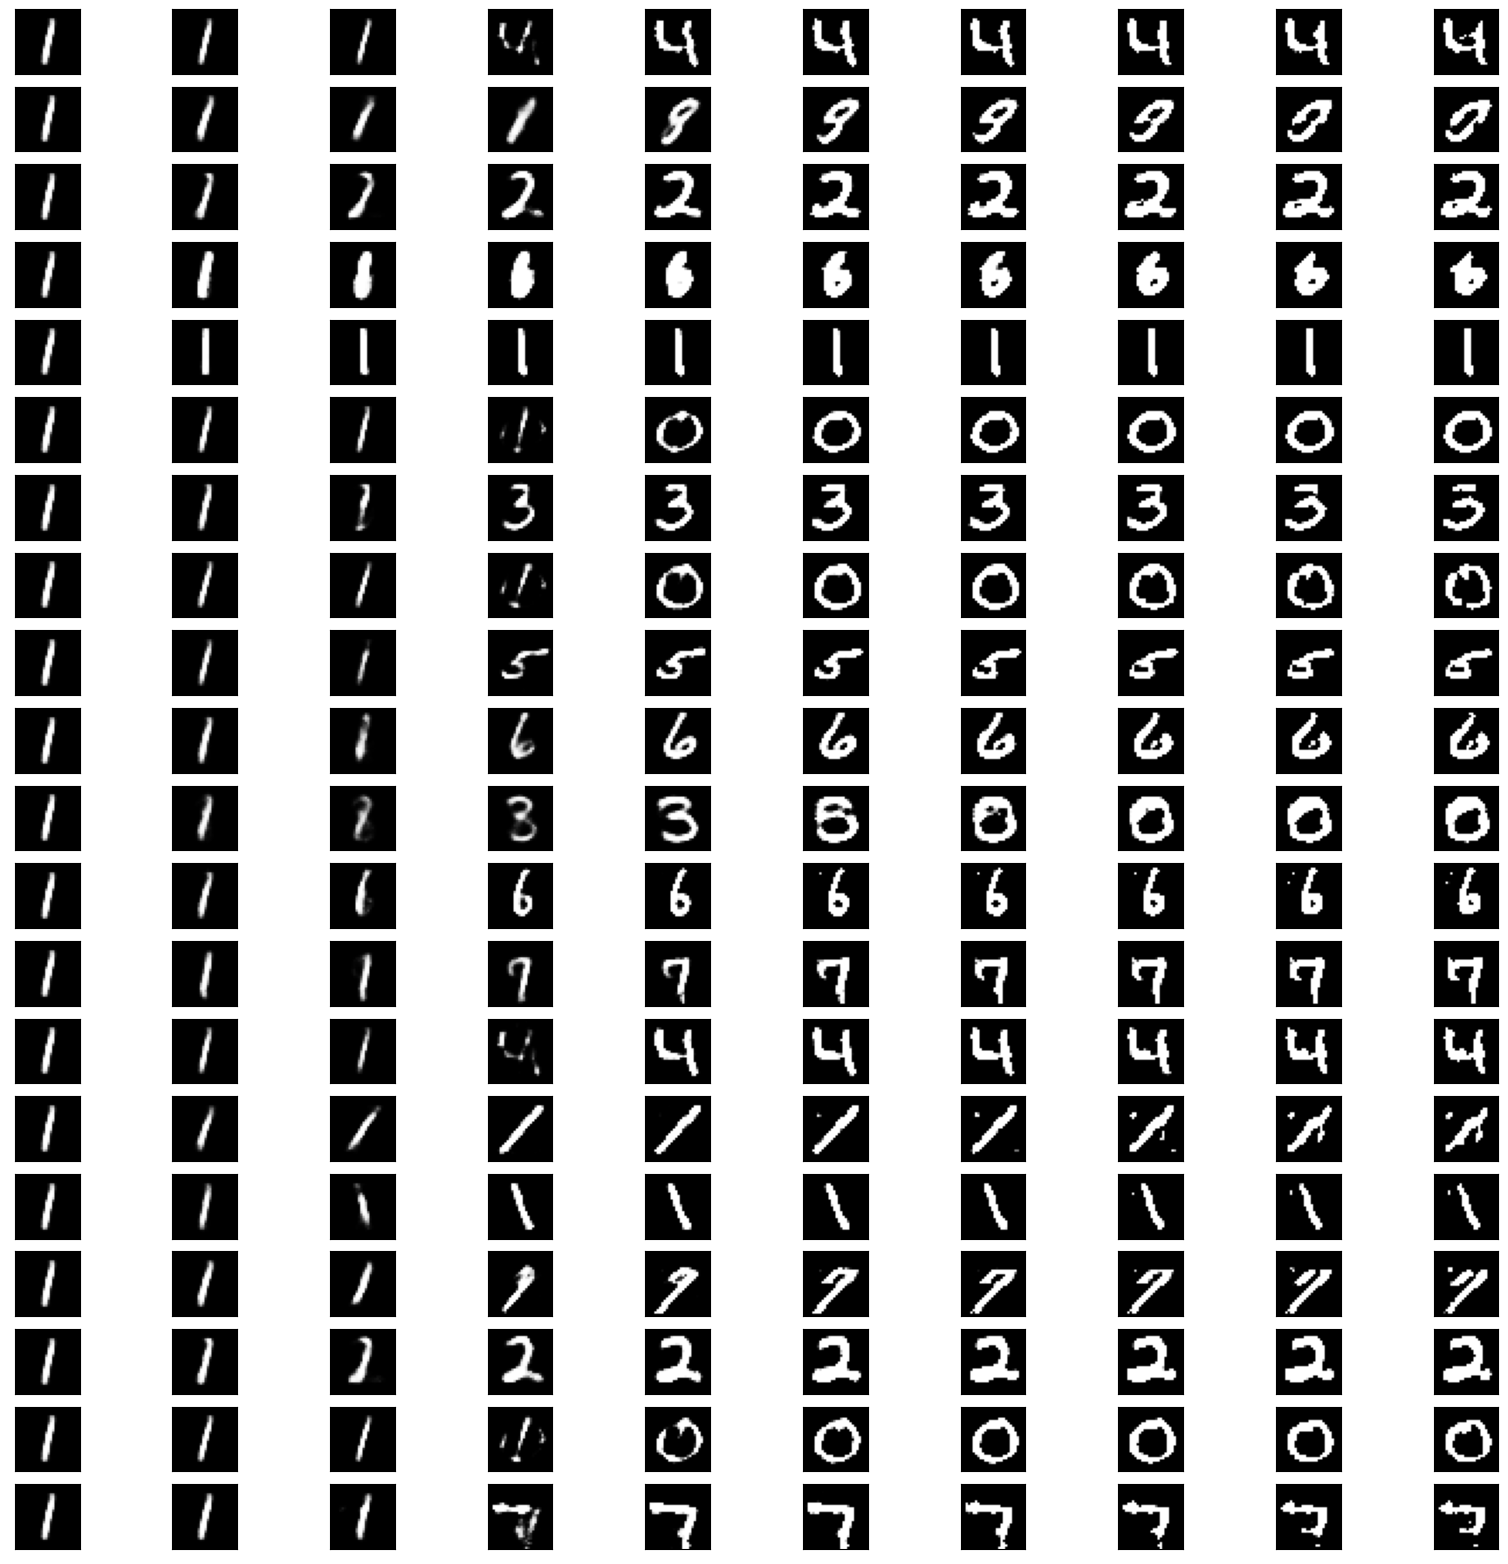

In [84]:
x = np.logspace(0, 2, 9)
x = np.concatenate(([0], x))

# sample 10 neurons
idx_neurons = np.random.choice(config["input_size"], 20, replace=False)

plt.figure(figsize=(20,20))
for i in range(len(idx_neurons)):
    for j in range(len(x)):
        plt.subplot(len(idx_neurons), len(x), i*len(x)+j+1)
        # generate latent activity
        activity = torch.zeros(1, config["input_size"])
        activity[0,idx_neurons[i]] = x[j]
        activity = activity.cuda() if use_cuda else activity
        output = gen_pc[1:](activity).sigmoid()
        plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray', vmin=0, vmax=1)
        plt.xticks([])
        plt.yticks([])
plt.show()

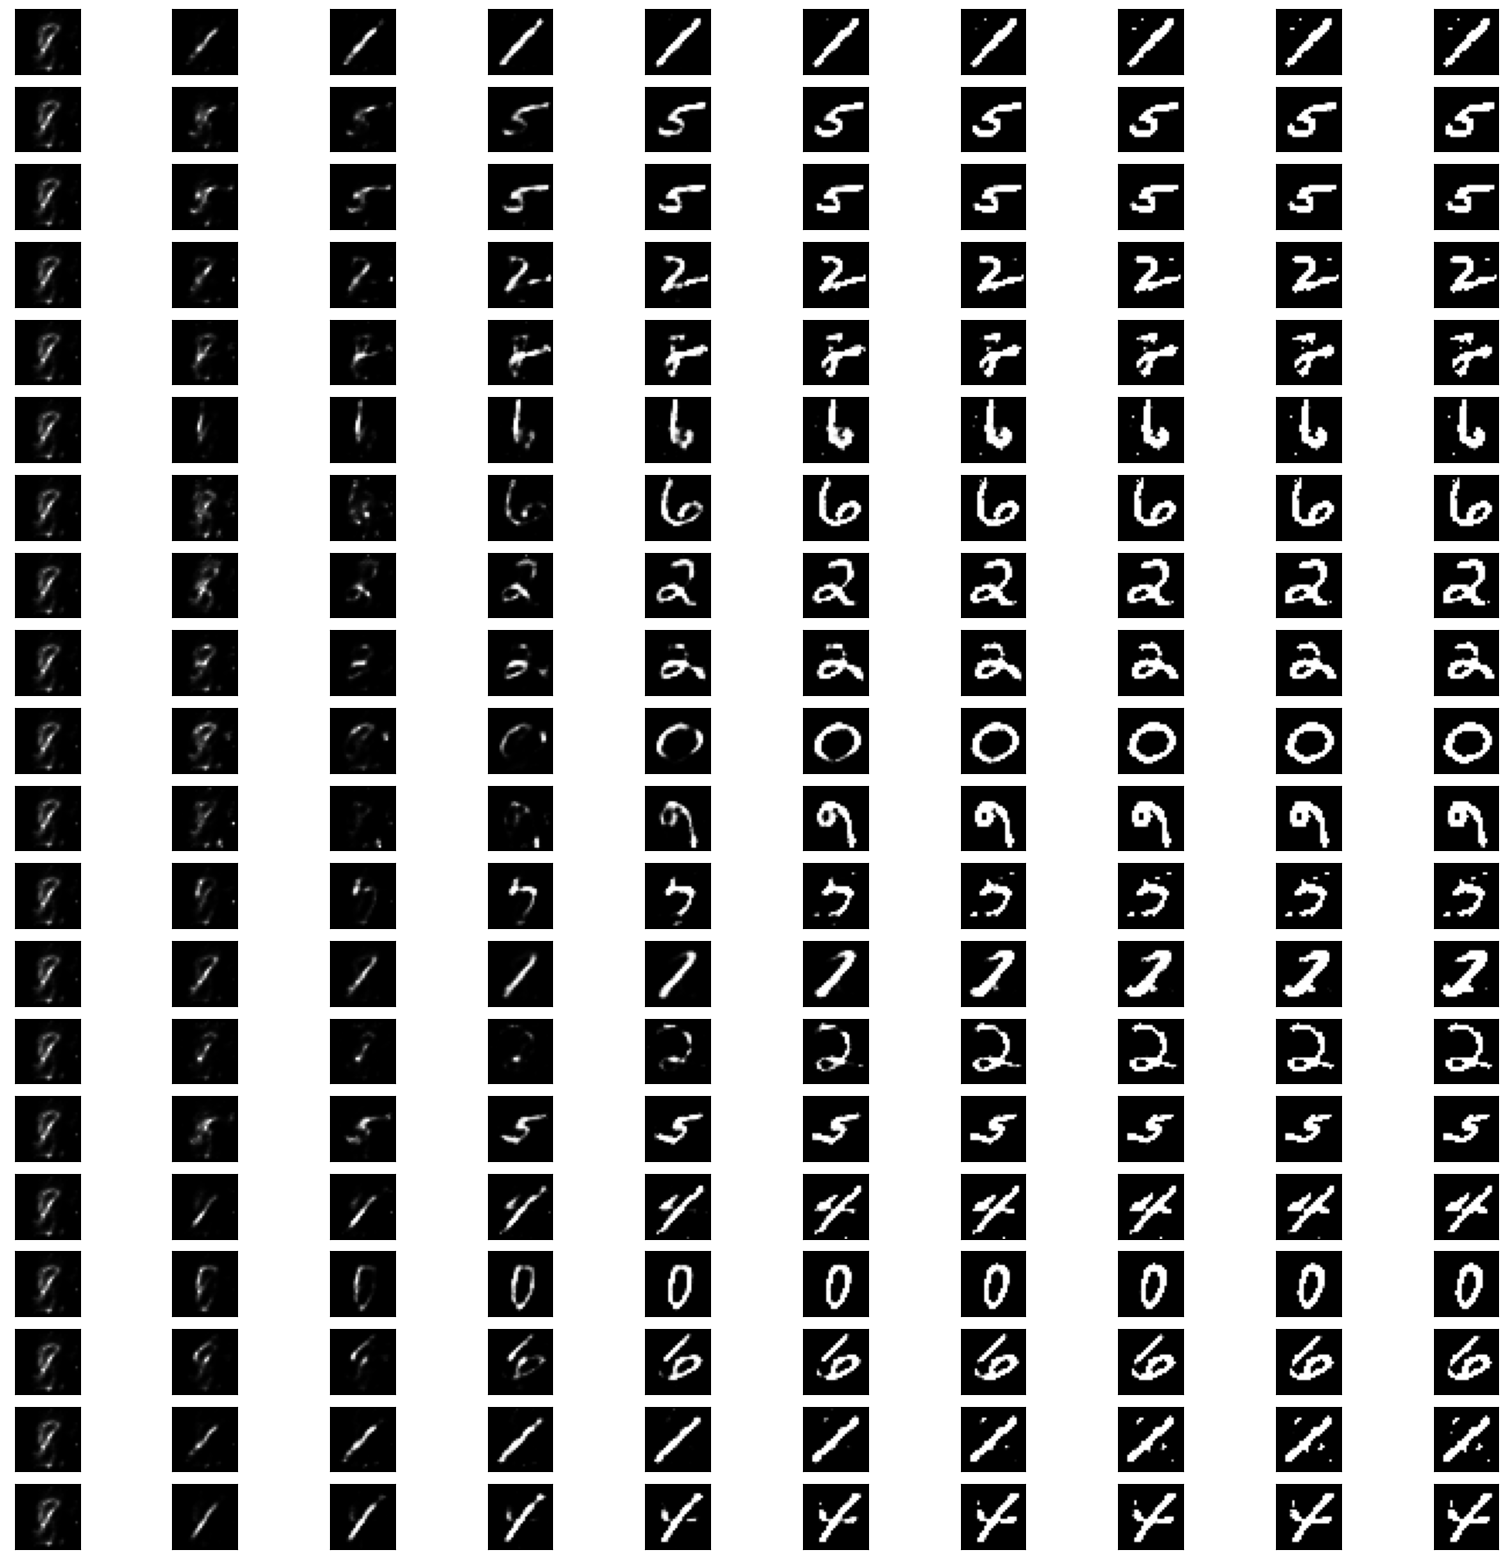

In [7]:
x = np.logspace(0, 2, 9)
x = np.concatenate(([0], x))

# sample 10 neurons
idx_neurons = np.random.choice(config["hidden_size"], 20, replace=False)

plt.figure(figsize=(20,20))
for i in range(len(idx_neurons)):
    for j in range(len(x)):
        plt.subplot(len(idx_neurons), len(x), i*len(x)+j+1)
        # generate latent activity
        activity = torch.zeros(1, config["hidden_size"])
        activity[0,idx_neurons[i]] = x[j]
        activity = activity.cuda() if use_cuda else activity
        output = gen_pc[4:](activity).sigmoid()
        plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray')
        plt.xticks([])
        plt.yticks([])
plt.show()

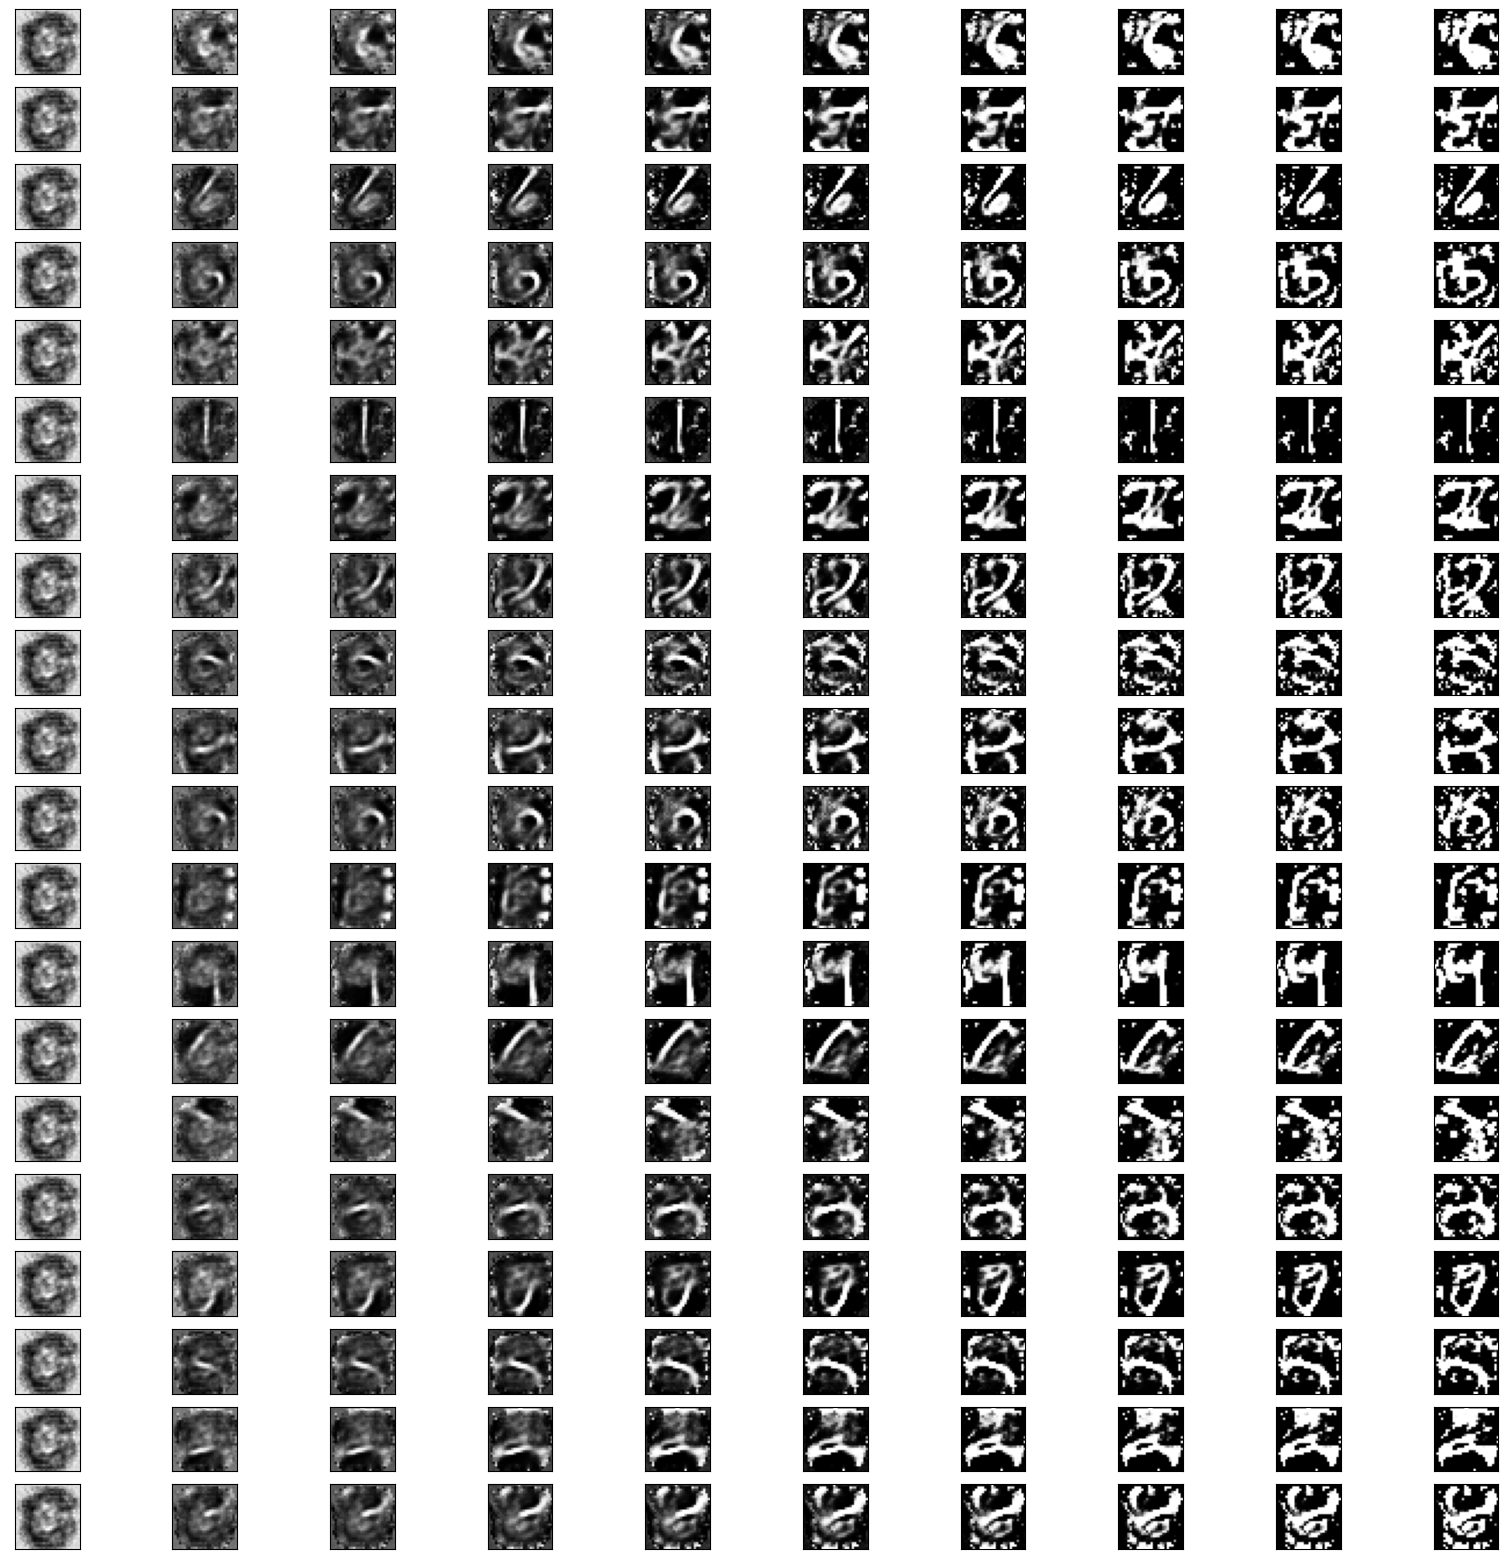

In [8]:
x = np.logspace(0, 2, 9)
x = np.concatenate(([0], x))

# sample 10 neurons
idx_neurons = np.random.choice(config["hidden_size"], 20, replace=False)

plt.figure(figsize=(20,20))
for i in range(len(idx_neurons)):
    for j in range(len(x)):
        plt.subplot(len(idx_neurons), len(x), i*len(x)+j+1)
        # generate latent activity
        activity = torch.zeros(1, config["hidden_size"])
        activity[0,idx_neurons[i]] = x[j]
        activity = activity.cuda() if use_cuda else activity
        output = gen_pc[7:](activity).sigmoid()
        plt.imshow(output.view(28,28).cpu().detach().numpy(), cmap='gray')
        plt.xticks([])
        plt.yticks([])
plt.show()

# benefit of PC warm-up inference

In [36]:
df[df[""] == "with pc warm-up"].groupby("T")["fid"].std()

T
10     2.895312
50     3.540854
100    9.600101
200    3.870352
500    0.896045
Name: fid, dtype: float64

In [72]:
df[df[""] == "without warm-up" ]["fid"]

0      60.105761
1      61.460852
2      63.158526
3      63.471154
4      64.935881
5      65.333050
6      73.076118
7      74.625742
8      76.783606
9      88.152159
10     90.206658
11     90.236529
12    131.698479
13    136.071309
14    159.305168
Name: fid, dtype: float64

In [50]:
df["T"].unique()[::-1]

array([ 10,  50, 100, 200, 500], dtype=int64)

In [3]:
sns.__version__

'0.12.0'

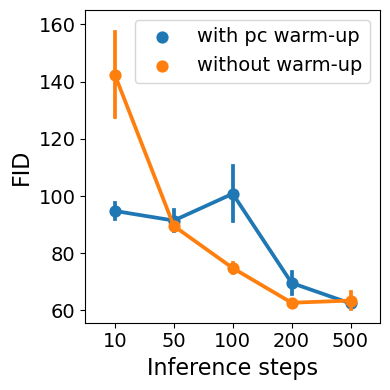

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

without_pc = pd.read_csv("mnist_without_pc_inference.csv")
with_pc = pd.read_csv("mnist_with_pc_inference.csv")

# combine with_pc and without_pc
with_pc[""] = "with pc warm-up"
without_pc[""] = "without warm-up"
df = pd.concat([with_pc, without_pc])

setup_fig()
sns.pointplot(data=df, x="T", y="fid", hue="", linestyles="-", errorbar="sd", estimator=np.mean)
plt.ylabel("FID")
plt.xlabel("Inference steps")
plt.yticks(np.arange(60,180,20), labels=np.arange(60,180,20))
plt.ylim(None, 165)
plt.tight_layout()
plt.savefig("figures/SI_mnist_warmup.svg")
plt.show()

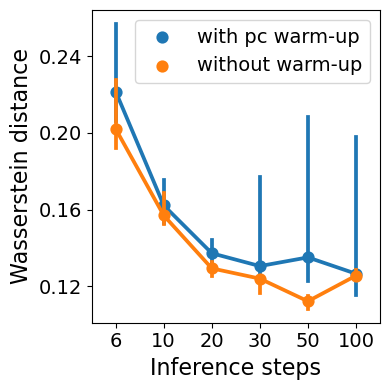

In [23]:
without_pc = pd.read_csv("iris_without_pc_inference.csv")
with_pc = pd.read_csv("iris_with_pc_inference.csv")

# combine with_pc and without_pc
with_pc[""] = "with pc warm-up"
without_pc[""] = "without warm-up"
df = pd.concat([with_pc, without_pc])

setup_fig(zero=True)
sns.pointplot(data=df, x="inference_steps", y="ot_final", hue="", linestyles="-", errorbar=("pi",50), estimator=np.median)
plt.ylabel("Wasserstein distance")
plt.xlabel("Inference steps")
plt.yticks(np.arange(0.12,0.26,0.04))
plt.tight_layout()
plt.savefig("figures/SI_iris_warmup.svg")
plt.show()

In [81]:
df[df[""] == "with pc warm-up" ].groupby("inference_steps").describe()

ot_final                                                    \
                   count      mean       std       min       25%       50%   
inference_steps                                                              
6                   10.0  0.228615  0.038886  0.173775  0.206392  0.221510   
10                  10.0  0.172907  0.035112  0.146211  0.153042  0.162195   
20                  10.0  0.144540  0.028786  0.125807  0.129114  0.137249   
30                  10.0  0.152655  0.042307  0.117810  0.126041  0.130562   
50                  10.0  0.160935  0.046444  0.114301  0.122707  0.135101   
100                 10.0  0.151711  0.044563  0.107597  0.115564  0.126581   

                                    Runtime        ...  seed         ot  \
                      75%       max   count  mean  ...   75%  max count   
inference_steps                                    ...                    
6                0.256580  0.294616    10.0  47.9  ...  6.75  9.0  10.0   
10               0.175595  0.266297    10.0  52.2  ...  6.75  9.0  10.0   
20               0.144197  0.223523    10.0  53.7  ...  6.75  9.0  10.0   
30               0.176963  0.227061    10.0  53.6  ...  6.75  9.0  10.0   
50               0.208033  0.225810    10.0  57.5  ...  6.75  9.0  10.0   
100              0.197851  0.210877    10.0  69.0  ...  6.75  9.0  10.0   

                                                                             \
                     mean       std       min       25%       50%       75%   
inference_steps                                                               
6                0.233682  0.031142  0.203078  0.217356  0.223961  0.230816   
10               0.198853  0.051263  0.132842  0.156930  0.184579  0.247377   
20               0.154758  0.032286  0.123106  0.136382  0.141962  0.159913   
30               0.161381  0.043781  0.119563  0.126433  0.137516  0.195698   
50               0.159834  0.044354  0.111017  0.119774  0.153889  0.195881   
100              0.152579  0.050544  0.102809  0.115495  0.122965  0.205808   

                           
                      max  
inference_steps            
6                0.303531  
10               0.273626  
20               0.225583  
30               0.233953  
50               0.226471  
100              0.220596  

[6 rows x 40 columns]

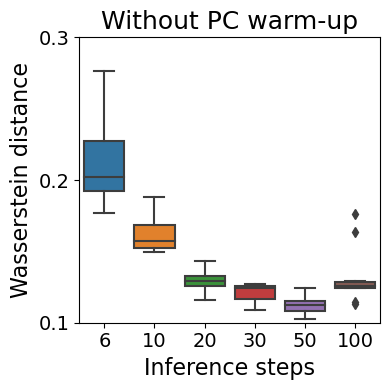

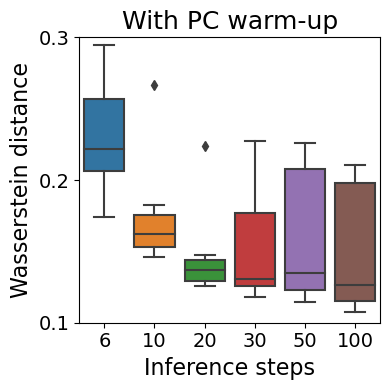

In [39]:
# load iris_with_pc_inference.csv using pandas
without_pc = pd.read_csv("iris_without_pc_inference.csv")
with_pc = pd.read_csv("iris_with_pc_inference.csv")

setup_fig()
sns.boxplot(data=without_pc, x="inference_steps", y="ot_final", )
plt.ylabel("Wasserstein distance")
plt.xlabel("Inference steps")
plt.yticks(np.arange(0.1,0.40, 0.1))
plt.title("Without PC warm-up")
plt.ylim(0.1,0.3)
plt.tight_layout()
plt.savefig("figures/iris_warmup_1.svg")


plt.figure()
setup_fig()
sns.boxplot(data=with_pc, x="inference_steps", y="ot_final", )
plt.ylabel("Wasserstein distance")
plt.xlabel("Inference steps")
plt.yticks(np.arange(0.1,0.40, 0.1))
plt.title("With PC warm-up")
plt.ylim(0.1,0.3)
plt.tight_layout()
plt.savefig("figures/iris_warmup_2.svg")
